#Introduction

This project analyzes data from on-line dating application OKCupid. In recent years, there has been a massive rise in the usage of dating apps. Most of these apps use sophisticated data science techniques to recommend possible matches to users and to optimize the user experience. These apps give us access to a wealth of information that we've never had before about how different people experience romance.

The goal of this project is to scope, prepare, analyze data and create a machine learning model to solve a question.


**Data sources:**

`profiles.csv` was provided by Codecademy.com.

## Scoping

### Project Goals

In this project, we aim to utilize the skills learned from Codecademy to apply machine learning techniques on a data set. The project will adress several issues. Main goal is to prepare the dataset to serve as basis for a recommendation model for users. That kind of recommendation is crucial for dating websites. We cannot use supervised learning because we do not have any data on users choices unfortunately. Without this data we cannot train a recommendation model. So we will try to fill missing data using other ML technichues instead. Classification and regression models can help fill in missing data for users to improve the performance of the recommendation model.
1.   Create a classification model that predicts whether a user smokes, uses drugs, drinks, has pets, engages in sex, has a job, or follows a particular diet, based on other features in the dataset.
2.   Create a regression model that predicts a user's age and height, based on their other features.

Classification and regression models will be useful to fill data user omitted to improve potential recomendation model performance.


### Data

The project has one data set provided by Codecademy called `profiles.csv`. In the data, each row represents an OkCupid user and the columns are the responses to their user profiles which include multi-choice and short answer questions.

### Analysis

This solution will use descriptive statistics and data visualization to find key figures in understanding the distribution, count, and relationship between variables. Since the goal of the project is to prepare data for a  recommendation model classification and regression models will be used to fill blanks in data to improve recommendation model performance.

### Evaluation

The project will conclude with the evaluation of classification and regression models selected with a validation data set. The output of the predictions can be checked through a confusion matrix, and metrics such as accuracy, precision, recall, F1 and Kappa scores.


###Import Python modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier



plt.rcParams['figure.figsize'] = [4, 4]
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Connect to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data

###Loading the data

We will be using pandas to load the dataset into a 'DataFrame'. Than we will use it to explore data features and create visualisations using 'matplotlib' and 'seaborn' libraries.

Here we load the 'profiles.csv' to 'DataFrame' called 'df_profiles_all'. The 'DataFrame' is then briefly examined using '.head()' and '.info()' dataframe methods to check contents and data types.

In [3]:
df_profiles_all = pd.read_csv('/content/drive/MyDrive/profiles.csv', on_bad_lines='skip', engine='python')
df_profiles_all.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


Check the data types in dataframe columns.

In [4]:
df_profiles_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   essay0       54458 non-null  object 
 7   essay1       52374 non-null  object 
 8   essay2       50308 non-null  object 
 9   essay3       48470 non-null  object 
 10  essay4       49409 non-null  object 
 11  essay5       49096 non-null  object 
 12  essay6       46175 non-null  object 
 13  essay7       47495 non-null  object 
 14  essay8       40721 non-null  object 
 15  essay9       47343 non-null  object 
 16  ethnicity    54266 non-null  object 
 17  height       59943 non-null  float64
 18  income       59946 non-null  int64  
 19  job 

#### Data Characteristics


The columns in the dataset include:

- **age:** continuous variable of age of user
- **body_type:** categorical variable of body type of user
- **diet:** categorical variable of dietary information
- **drinks:**  categorical variable of alcohol consumption
- **drugs:** categorical variable of drug usage
- **education:** categorical variable of educational attainment
- **ethnicity:** categorical variable of ethnic backgrounds
- **height:** continuous variable of height of user
- **income:** continuous variable of income of user
- **job:** categorical variable of employment description
- **offspring:** categorical variable of children status
- **orientation:** categorical variable of sexual orientation
- **pets:** categorical variable of pet preferences
- **religion:** categorical variable of religious background
- **sex:** categorical variable of gender
- **sign:** categorical variable of astrological symbol
- **smokes:** categorical variable of smoking consumption
- **speaks:** categorical variable of language spoken
- **status:** categorical variable of relationship status
- **last_online:** date variable of last login
- **location:** categorical variable of user locations

And a set of open short-answer responses to :

- **essay0:** My self summary
- **essay1:**  What I’m doing with my life
- **essay2:** I’m really good at
- **essay3:** The first thing people usually notice about me
- **essay4:** Favorite books, movies, show, music, and food
- **essay5:** The six things I could never do without
- **essay6:** I spend a lot of time thinking about
- **essay7:** On a typical Friday night I am
- **essay8:** The most private thing I am willing to admit
- **essay9:** You should message me if…

In [5]:
list(df_profiles_all.columns)

['age',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'essay0',
 'essay1',
 'essay2',
 'essay3',
 'essay4',
 'essay5',
 'essay6',
 'essay7',
 'essay8',
 'essay9',
 'ethnicity',
 'height',
 'income',
 'job',
 'last_online',
 'location',
 'offspring',
 'orientation',
 'pets',
 'religion',
 'sex',
 'sign',
 'smokes',
 'speaks',
 'status']

##Explore the data


First we should explore every column. Check for some insights and patterns in the data. Check if we need to make some changes to data before we start creating our models.

### Continuous Variables

####Age

Print out unique values of age and check for erroneous data.

In [6]:
print(df_profiles_all['age'].unique())

[ 22  35  38  23  29  32  31  24  37  28  30  39  33  26  27  20  25  40
  36  21  34  43  46  41  42  45  18  55  50  59  44  48  54  51  62  52
  19  58  66  53  63  47  49  61  60  57  56  65  64  68 110  69  67 109]


The next plot shows the distribution of age in the dataset broken down by gender. It seems that most users are in their late 20s to early 30s. It seems that there are proportionally similar break down of gender by age, but slightly fewer females overall.

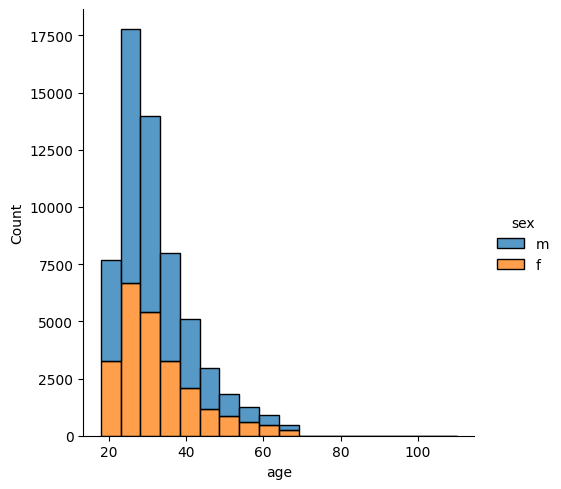

In [7]:
sns.displot(data=df_profiles_all, x="age", hue="sex", kind="hist", binwidth = 5, multiple = "stack");

So we have about 50 % more male users.

In [8]:
df_profiles_all['sex'].value_counts(normalize=True)

,proportion
sex,
m,0.597688
f,0.402312


#### Height

The next plot shows the height variable, separate for male and female. Distribution looks normal for both male and females. Females tend to be smaller.

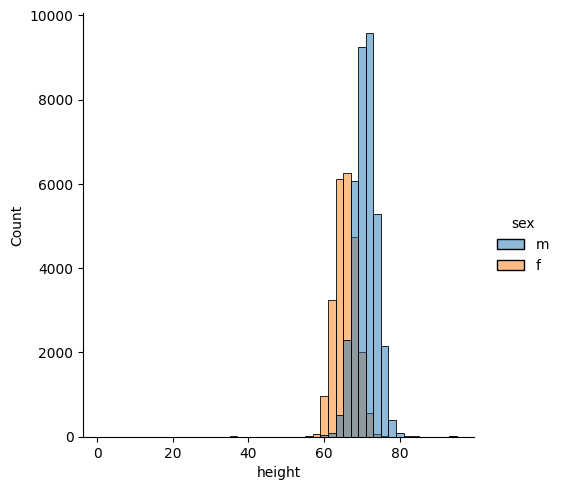

In [9]:
sns.displot(data=df_profiles_all, x="height", kind="hist", hue='sex', binwidth = 2);

Check median height values for both genders. Median value for males is 5 inches higher.

In [10]:
df_profiles_all.groupby('sex')['height'].median()

,height
sex,
f,65.0
m,70.0


#### Income

Here is the data of income, it seems that the majority of the participants do not include their income figures.

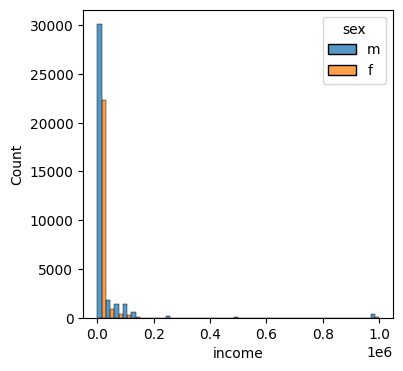

In [11]:
sns.histplot(data=df_profiles_all, x='income', hue='sex', binwidth=30000, multiple='dodge');

### Discrete Variables

#### Sex

Previously it was identified that there are more males in the data, 35,829 men to 24,117 women.

In [12]:
df_profiles_all['sex'].value_counts()

,count
sex,
m,35829
f,24117


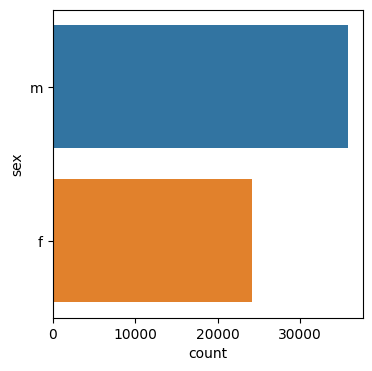

In [13]:
sns.countplot(data=df_profiles_all, y="sex", hue='sex');

#### Body Type

The next chart shows the body type variable for both genders. Most popular choices for males are athletic, average or fit. Most popular choices for females are average, fit and curvy. Fit and especially athletic build is very male specific. Curvy and full figured are female specific.

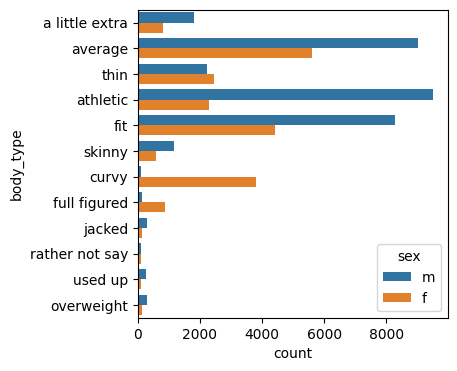

In [14]:
sns.countplot(data=df_profiles_all, y="body_type", hue='sex');

#### Diet

Here is a chart of the dietary information for users. Most user eat "mostly anything", followed by "anything", and "strictly anything", being open-minded seems to be a popular signal to potential partners. Vegetarian options are more popular among females.

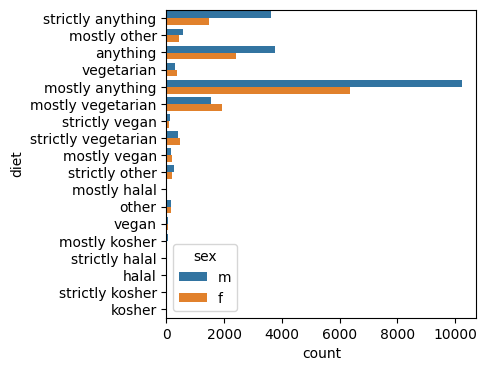

In [15]:
sns.countplot(data=df_profiles_all, y="diet", hue='sex');

Religios diets are not very popular on dating website.

In [16]:
df_profiles_all['diet'].value_counts()

,count
diet,
mostly anything,16585
anything,6183
strictly anything,5113
mostly vegetarian,3444
mostly other,1007
strictly vegetarian,875
vegetarian,667
strictly other,452
mostly vegan,338


#### Drinks

The next plot shows that the majority of the users drink "socially", then "rarely" and "often". No significant gender difference, that is interesting.

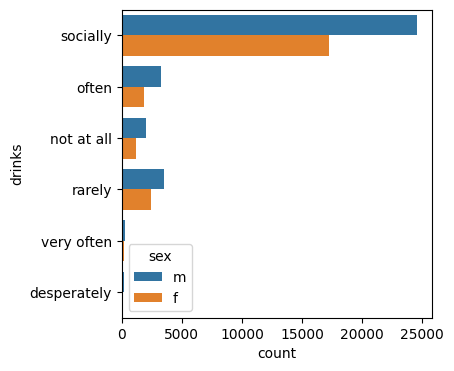

In [17]:
sns.countplot(data=df_profiles_all, y="drinks", hue='sex');

#### Drugs

The vast majority of users "never" use drugs. Also no gender difference.

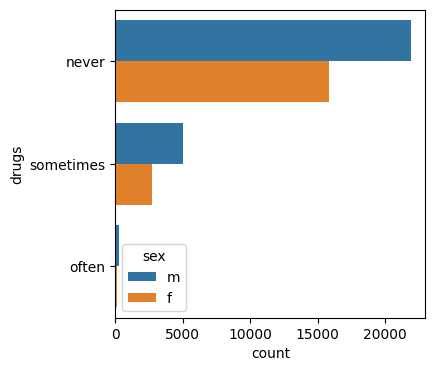

In [18]:
sns.countplot(data=df_profiles_all, y="drugs", hue='sex');

#### Education

Below you can see the majority of users are graduate from college/university followed by masters programs and those working on college/university. Interestingly space camp related options are fairly a popular options. Also note that there are significantly more females working on and graduated masters programs. And significantly more males dropped out of college/univercity.

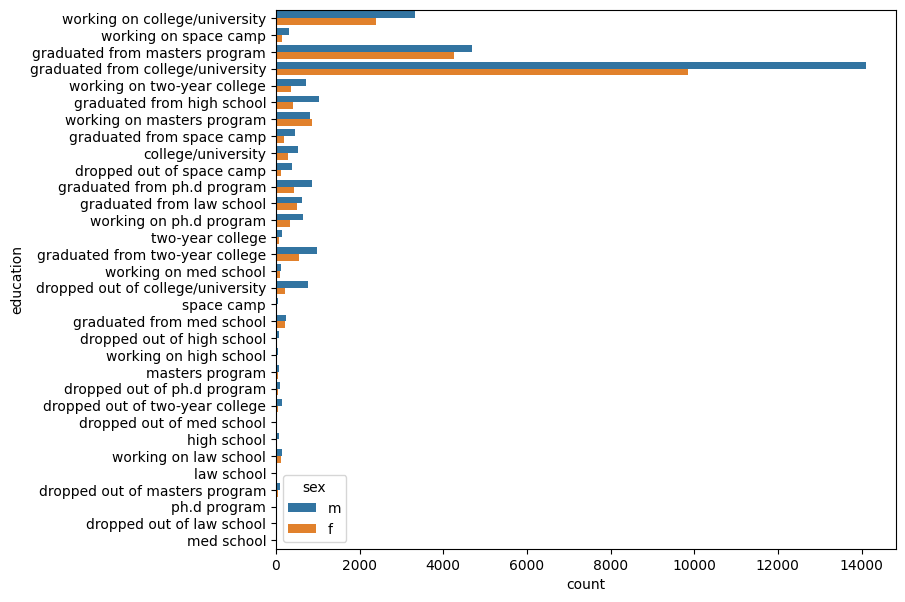

In [19]:
# set figure size
plt.figure(figsize=(8,7))
sns.countplot(data=df_profiles_all, y="education", hue='sex');

#### Jobs

Most users don't fit into the categories provided, but there are a fair share of students, artists, tech, and business folks. Note the prevalence of females in education/academia, medicine/health and clerical/administrative. And prevalence of males in computer/hardware/software, science/tech/engineering, transportation and (as expected) military.

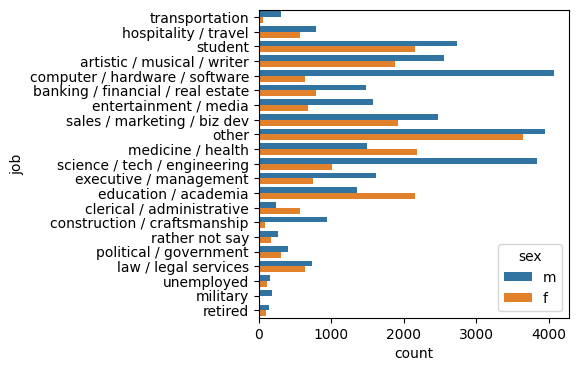

In [20]:
sns.countplot(data=df_profiles_all, y="job", hue='sex');

#### Offspring

The data suggest that most users do not have kids. Note that significantly more females indicate that they have kids. And looks like females want kids more often.

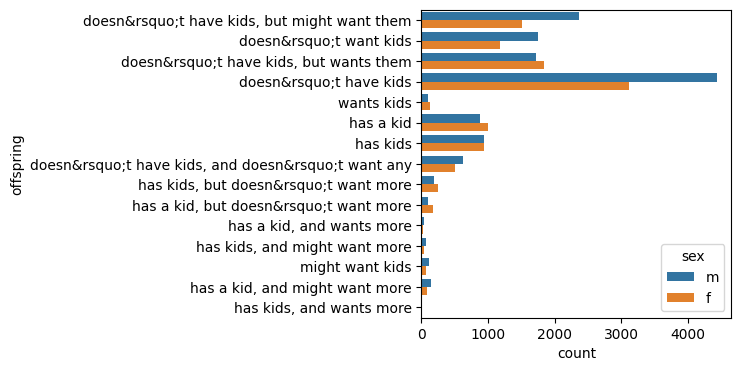

In [21]:
sns.countplot(data=df_profiles_all, y="offspring", hue='sex');

#### Orientation

The majority of users are straight. There are much more females among bisexual users.

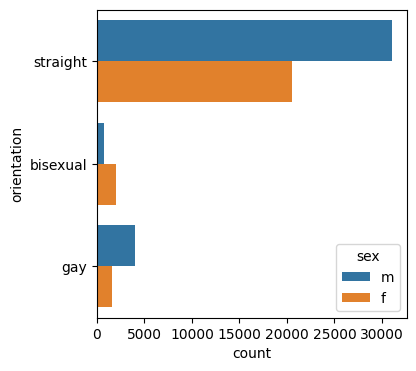

In [22]:
sns.countplot(data=df_profiles_all, y="orientation", hue='sex');

#### Pets

The chart shows that most users are fond of animals.

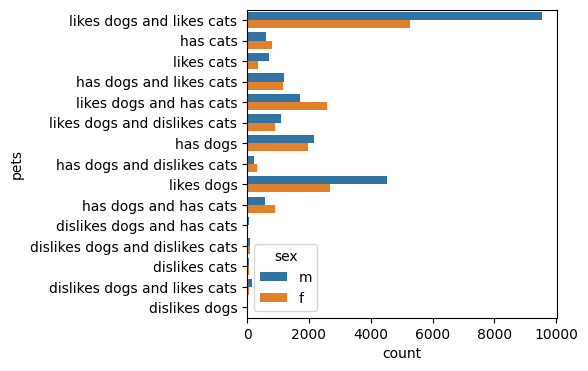

In [23]:
sns.countplot(data=df_profiles_all, y="pets", hue='sex');

In [24]:
df_profiles_all['pets'].value_counts()

,count
pets,
likes dogs and likes cats,14814
likes dogs,7224
likes dogs and has cats,4313
has dogs,4134
has dogs and likes cats,2333
likes dogs and dislikes cats,2029
has dogs and has cats,1474
has cats,1406
likes cats,1063


#### Religion

Religion was similar to sign where there are a lot of qualifiers. Females tend to be more serious about that question.

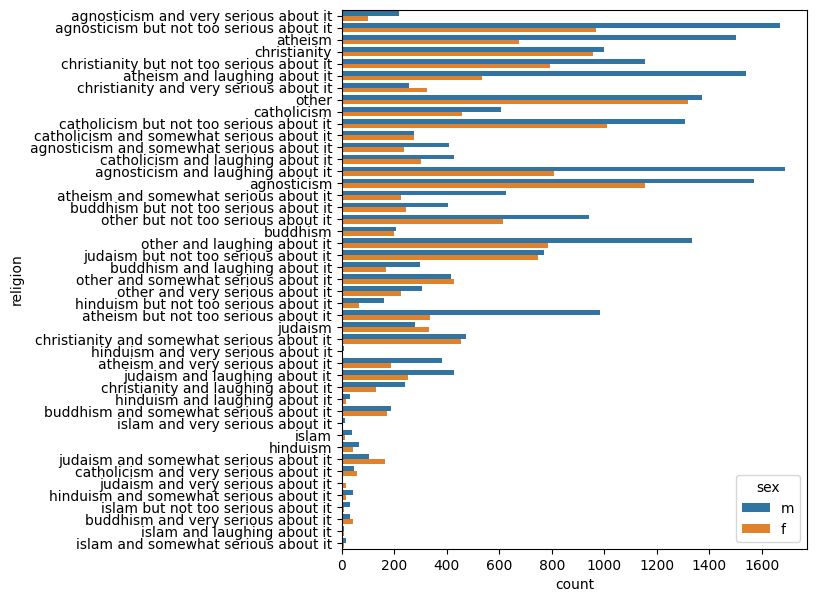

In [25]:
# set figure size
plt.figure(figsize=(6,7))
sns.countplot(data=df_profiles_all, y="religion", hue='sex');

Religion was cleaned to take the first word and distilled down to 9 groups. The majority was not very religious identifying as agnostic, other, or atheists.

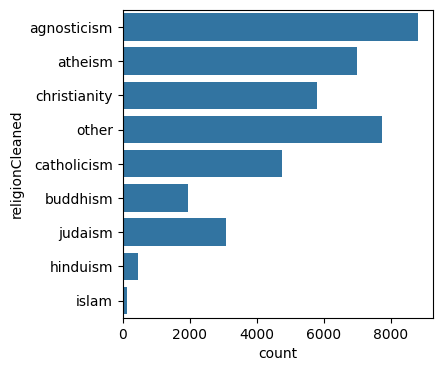

In [26]:
df_profiles_all['religionCleaned'] = df_profiles_all.religion.str.split().str.get(0)
sns.countplot(data=df_profiles_all, y="religionCleaned");

#### Signs

There are a lot of options in that column. We will create signsCleaned column with signs without qualifiers. Signs are mainly evenly distributed with Capricorns being the rarest and Leos being the most common.

In [27]:
df_profiles_all['signsCleaned'] = df_profiles_all.sign.str.split().str.get(0)
df_profiles_all.signsCleaned.value_counts()

,count
signsCleaned,
leo,4374
gemini,4310
libra,4207
cancer,4206
virgo,4141
taurus,4140
scorpio,4134
aries,3989
pisces,3946


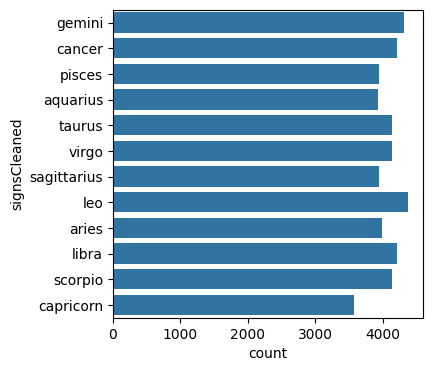

In [28]:
sns.countplot(data=df_profiles_all, y="signsCleaned");

#### Smoking

Similarly for drugs the majority of users chose "no" for smoking.

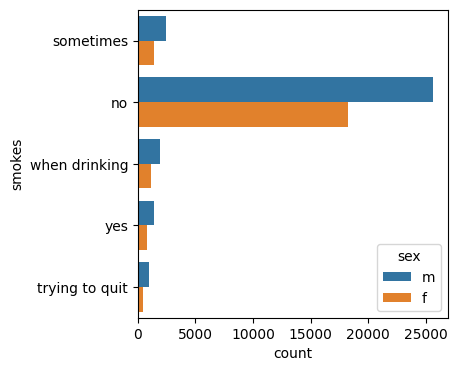

In [29]:
sns.countplot(data=df_profiles_all, y="smokes", hue='sex');

#### Status

The relationship status for a dating website for most users is 'single' as it can be expected.

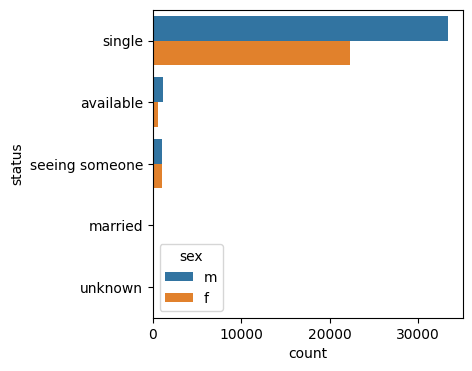

In [30]:
sns.countplot(data=df_profiles_all, y="status", hue='sex');

Turns out that somehow 2064 users are seeing someone.

In [31]:
df_profiles_all.status.value_counts()

,count
status,
single,55697
seeing someone,2064
available,1865
married,310
unknown,10


A bit more females are in such strange status.

In [32]:
df_profiles_all[df_profiles_all['status'] == 'seeing someone']['sex'].value_counts()

,count
sex,
m,1061
f,1003


#### Ethnicity

As can be expected there are a lot of ethnic groups in our dataset. If we later create dummy columns for all of these groups, it will be computationally expensive. We will create columns for the main ethnic groups - white, black, hispanic, middle eastern, native american and so on.

In [33]:
df_profiles_all.ethnicity.unique()

array(['asian, white', 'white', nan, 'asian, black, other',
       'white, other', 'hispanic / latin, white', 'hispanic / latin',
       'pacific islander, white', 'asian', 'black, white',
       'pacific islander', 'asian, native american',
       'asian, pacific islander', 'black, native american, white',
       'middle eastern, other', 'native american, white', 'indian',
       'black', 'black, native american, hispanic / latin, other',
       'black, native american, hispanic / latin',
       'asian, black, pacific islander',
       'asian, middle eastern, black, native american, indian, pacific islander, hispanic / latin, white, other',
       'other', 'hispanic / latin, other', 'asian, black',
       'middle eastern, white', 'native american, white, other',
       'black, native american', 'black, white, other',
       'hispanic / latin, white, other', 'middle eastern', 'black, other',
       'native american, hispanic / latin, white', 'black, indian',
       'indian, white, othe

In [34]:
main_groups = ['white', 'black', 'latin', 'indian', 'asian', 'native american', 'middle eastern', 'pacific islander', 'hispanic']
for group in main_groups:
  column_name = f'is_{group.replace(" ", "_")}'
  df_profiles_all[column_name] = df_profiles_all['ethnicity'].apply(lambda x: group in str(x).lower())

In [35]:
df_profiles_all.columns

Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7',
       'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'location', 'offspring', 'orientation', 'pets',
       'religion', 'sex', 'sign', 'smokes', 'speaks', 'status',
       'religionCleaned', 'signsCleaned', 'is_white', 'is_black', 'is_latin',
       'is_indian', 'is_asian', 'is_native_american', 'is_middle_eastern',
       'is_pacific_islander', 'is_hispanic'],
      dtype='object')

Now we can drop original 'ethnicity' column.

In [36]:
df_profiles_all = df_profiles_all.drop('ethnicity', axis=1)

#### Location

As can be expected there are a lot of ethnical groups in our dataset. If we later create dummy columns for all of them that will be computationary expensive. We will create columns for main ethnical groups - white, black, hispanic, middle eastern, native american and so on.

In [37]:
len(df_profiles_all.location.unique())

199

In [38]:
locations_list = df_profiles_all.location.unique()
states_list = []
for location in locations_list:
  location_state = location.split(', ')[-1]
  if location_state not in states_list:
    states_list.append(location_state)
len(states_list)

41

####Speaks
First we check how many unique values there are in that column. Looks like the number is very big - 7648 values. We definitely should consider using that column in our models or at least keep it for future recommendation model, since language is significant factor in communication.

In [39]:
unique_speaks_values = df_profiles_all['speaks'].unique()

file_name = 'unique_speaks_languages.txt'
with open(file_name, 'w') as f:
    for item in unique_speaks_values:
        f.write(str(item) + '\n')

print(f"Unique 'speaks' values saved to {file_name}")

Unique 'speaks' values saved to unique_speaks_languages.txt


The `speaks` column contains multiple languages and proficiency levels in a single string. To make this data useful, we'll extract each unique language and create a new boolean column for it. For example, if a user speaks 'english (fluently)', a new column `speaks_english` will be created and set to `True` for that user.

In [40]:


def extract_languages_with_proficiency(speaks_entry):
    if pd.isna(speaks_entry):
        return []
    languages_with_proficiency = []
    for part in speaks_entry.split(','):
        # Extract the language name and optionally the proficiency in parentheses
        match = re.match(r'\s*([a-zA-Z\s]+)(?:\s*\((.*)\))?', part.strip())
        if match:
            language = match.group(1).strip().lower().replace(' ', '_')
            proficiency = match.group(2)
            if proficiency:
                proficiency = proficiency.strip().lower().replace(' ', '_')
                languages_with_proficiency.append(f'{language}_{proficiency}')
            else:
                languages_with_proficiency.append(language)
    return languages_with_proficiency

# Get all unique languages with their proficiencies
all_languages_with_proficiency = df_profiles_all['speaks'].apply(extract_languages_with_proficiency).explode().unique()

# Create new boolean columns for each unique language-proficiency combination
for lang_prof in all_languages_with_proficiency:
    if lang_prof and lang_prof != 'nan': # Exclude empty strings or 'nan' that might result from parsing
        df_profiles_all[f'speaks_{lang_prof}'] = df_profiles_all['speaks'].apply(lambda x: lang_prof in extract_languages_with_proficiency(x))

# Display the new columns and their types for verification
new_speaks_cols = [col for col in df_profiles_all.columns if col.startswith('speaks_') and '_' in col[len('speaks_'):]]
display(df_profiles_all[new_speaks_cols].head())

,speaks_english_fluently,speaks_spanish_poorly,speaks_french_poorly,speaks_german_poorly,speaks_chinese_okay,speaks_spanish_okay,speaks_sign_language_poorly,speaks_spanish_fluently,speaks_italian_okay,speaks_tagalog_fluently,...,speaks_frisian_poorly,speaks_belarusan_okay,speaks_armenian_okay,speaks_finnish_okay,speaks_tibetan_fluently,speaks_lithuanian_poorly,speaks_georgian_fluently,speaks_welsh_okay,speaks_breton_okay,speaks_frisian_fluently
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
display(df_profiles_all.columns)

Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3',
       ...
       'speaks_romanian', 'speaks_georgian_fluently', 'speaks_welsh_okay',
       'speaks_chechen', 'speaks_breton_okay', 'speaks_estonian',
       'speaks_breton', 'speaks_welsh', 'speaks_latvian',
       'speaks_frisian_fluently'],
      dtype='object', length=341)

Now we can drop original 'speaks' column.


In [42]:
df_profiles_all = df_profiles_all.drop('speaks', axis=1)

## Data Preparation


### Missing Data

Missing data is often not handled well by machine learning algorithms and needs to be checked for. Missing values may need to be filled in or removed. Many of the columns do have missing values, so I will try filling those values using machine learning models.

In [43]:
table_of_nan = df_profiles_all.isnull().sum().sort_values(ascending=False)
table_of_nan_not_null = table_of_nan[table_of_nan !=0]
table_of_nan_not_null

,0
offspring,35561
diet,24395
religionCleaned,20226
religion,20226
pets,19921
essay8,19225
drugs,14080
essay6,13771
essay9,12603
essay7,12451


### Preprocessing

Preparing the data for modelling is important as it can speed up the process and produce better models. "Garbage in - garbage out". So, we want to make sure the data we input into our model is good enough.

It looks like we have correct data type in all columns except possibly the last_online column. However, we won't use this specific column in our models as it won't benefit classification or regression models.
Now we need to check how many missing values there are in the dataframe.

In [44]:
missing_values_percentage = (df_profiles_all.isnull().sum() / len(df_profiles_all)) * 100
display(missing_values_percentage.sort_values(ascending=False))

,0
offspring,59.321723
diet,40.694959
religionCleaned,33.740366
religion,33.740366
pets,33.231575
...,...
speaks_japanese_fluently,0.000000
speaks_norwegian_poorly,0.000000
speaks_swedish_poorly,0.000000
speaks_indonesian_poorly,0.000000


As we can see we have considerable amount of missing values in several columns. If we simply drop that values we will loose very big chunk of our data. We can try to fill missing values with .fillna() method but it wouldn't be effective in most cases and will simply generate junk data. We will try to use regression and classisification instead.

We need to choose what columns we will be using in our regression and classification models.

In [45]:
df_profiles_all.columns

Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3',
       ...
       'speaks_romanian', 'speaks_georgian_fluently', 'speaks_welsh_okay',
       'speaks_chechen', 'speaks_breton_okay', 'speaks_estonian',
       'speaks_breton', 'speaks_welsh', 'speaks_latvian',
       'speaks_frisian_fluently'],
      dtype='object', length=340)

In [46]:
df_profiles_cleared = df_profiles_all.drop(['essay0',
       'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7',
       'essay8', 'essay9', 'last_online'], axis=1)
df_profiles_cleared.columns

Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'height',
       'income', 'job', 'location',
       ...
       'speaks_romanian', 'speaks_georgian_fluently', 'speaks_welsh_okay',
       'speaks_chechen', 'speaks_breton_okay', 'speaks_estonian',
       'speaks_breton', 'speaks_welsh', 'speaks_latvian',
       'speaks_frisian_fluently'],
      dtype='object', length=329)

In [47]:
columns_list = list(df_profiles_cleared.columns)
columns_list

['age',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'height',
 'income',
 'job',
 'location',
 'offspring',
 'orientation',
 'pets',
 'religion',
 'sex',
 'sign',
 'smokes',
 'status',
 'religionCleaned',
 'signsCleaned',
 'is_white',
 'is_black',
 'is_latin',
 'is_indian',
 'is_asian',
 'is_native_american',
 'is_middle_eastern',
 'is_pacific_islander',
 'is_hispanic',
 'speaks_english',
 'speaks_english_fluently',
 'speaks_spanish_poorly',
 'speaks_french_poorly',
 'speaks_french',
 'speaks_c',
 'speaks_german_poorly',
 'speaks_chinese_okay',
 'speaks_spanish_okay',
 'speaks_sign_language_poorly',
 'speaks_spanish_fluently',
 'speaks_italian_okay',
 'speaks_tagalog_fluently',
 'speaks_japanese_okay',
 'speaks_other_fluently',
 'speaks_thai_poorly',
 'speaks_russian',
 'speaks_dutch_fluently',
 'speaks_lisp_fluently',
 'speaks_german_okay',
 'speaks_indonesian_fluently',
 'speaks_english_okay',
 'speaks_portuguese_poorly',
 'speaks_swedish_fluently',
 'speaks_belarusan'

Checking how many unique values are in each column. This way we can estimate amount of dummy columns we will get when we apply pd.dummy().

In [48]:
dict_of_lengths = {}
for column in df_profiles_cleared.columns:
  dict_of_lengths[column] = len(df_profiles_cleared[column].unique())
dict_of_lengths

{'age': 54,
 'body_type': 13,
 'diet': 19,
 'drinks': 7,
 'drugs': 4,
 'education': 33,
 'height': 61,
 'income': 13,
 'job': 22,
 'location': 199,
 'offspring': 16,
 'orientation': 3,
 'pets': 16,
 'religion': 46,
 'sex': 2,
 'sign': 49,
 'smokes': 6,
 'status': 5,
 'religionCleaned': 10,
 'signsCleaned': 13,
 'is_white': 2,
 'is_black': 2,
 'is_latin': 2,
 'is_indian': 2,
 'is_asian': 2,
 'is_native_american': 2,
 'is_middle_eastern': 2,
 'is_pacific_islander': 2,
 'is_hispanic': 2,
 'speaks_english': 2,
 'speaks_english_fluently': 2,
 'speaks_spanish_poorly': 2,
 'speaks_french_poorly': 2,
 'speaks_french': 2,
 'speaks_c': 2,
 'speaks_german_poorly': 2,
 'speaks_chinese_okay': 2,
 'speaks_spanish_okay': 2,
 'speaks_sign_language_poorly': 2,
 'speaks_spanish_fluently': 2,
 'speaks_italian_okay': 2,
 'speaks_tagalog_fluently': 2,
 'speaks_japanese_okay': 2,
 'speaks_other_fluently': 2,
 'speaks_thai_poorly': 2,
 'speaks_russian': 2,
 'speaks_dutch_fluently': 2,
 'speaks_lisp_fluently'

Now we apply pd.get_dummies() to create a table suitable for machine learning models.

In [49]:
df_profiles_dummy = pd.get_dummies(df_profiles_cleared)
df_profiles_dummy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Columns: 762 entries, age to signsCleaned_virgo
dtypes: bool(759), float64(1), int64(2)
memory usage: 44.8 MB


In [50]:
df_profiles_dummy.head()

,age,height,income,is_white,is_black,is_latin,is_indian,is_asian,is_native_american,is_middle_eastern,...,signsCleaned_cancer,signsCleaned_capricorn,signsCleaned_gemini,signsCleaned_leo,signsCleaned_libra,signsCleaned_pisces,signsCleaned_sagittarius,signsCleaned_scorpio,signsCleaned_taurus,signsCleaned_virgo
0,22,75.0,-1,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,35,70.0,80000,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,38,68.0,-1,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,23,71.0,20000,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,29,66.0,-1,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


# Analysis

We start with regression models. We will try to create machine learning model to predict 'age' and 'height' columns values based on other columns values.

## Regression models


### Regression using RandomForestRegressor

First we try RandomForestRegressor.

####Age

Create a train and test data sets with 'age' as target variable.

In [51]:
X_age = df_profiles_dummy.drop('age', axis=1)
y_age = df_profiles_dummy['age']

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(X_age, y_age, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train_age.shape}")
print(f"X_test shape: {X_test_age.shape}")
print(f"y_train shape: {y_train_age.shape}")
print(f"y_test shape: {y_test_age.shape}")

X_train shape: (47956, 761)
X_test shape: (11990, 761)
y_train shape: (47956,)
y_test shape: (11990,)


Create an instance of RandomForestRegressor and fit it on a training data set.

In [52]:
# Create a RandomForestRegressor model instance
model_age = RandomForestRegressor(random_state=42)

# Train the model
model_age.fit(X_train_age, y_train_age)

print("RandomForestRegressor model for age prediction created and trained.")

RandomForestRegressor model for age prediction created and trained.


Predict values of 'age' on a test data set.

In [53]:
y_pred_age = model_age.predict(X_test_age)
print("Predicted ages for X_test (first 5 values):")
print(y_pred_age[:5])

Predicted ages for X_test (first 5 values):
[26.64 32.45 27.56 28.68 28.56]


Evaluate model performance using 'mean_squared_error' and 'r2_score' from sklearn.metrics

In [54]:
# Calculate Mean Squared Error
mse_age = mean_squared_error(y_test_age, y_pred_age)

# Calculate Root Mean Squared Error
rmse_age = np.sqrt(mse_age)

# Calculate R-squared score
r2_age = r2_score(y_test_age, y_pred_age)

print(f"Root Mean Squared Error (RMSE): {rmse_age:.2f}")
print(f"R-squared (R2) Score: {r2_age:.2f}")

Root Mean Squared Error (RMSE): 7.47
R-squared (R2) Score: 0.38


RMSE indicates that, on average, the model's predictions are about 7.47 years off from the actual age. The R-squared score of 0.38 suggests that approximately 38% of the variance in age can be explained by the model. Not a bad result.

##### Feature Importance for Age Prediction

Feature importance quantifies the contribution of each feature to the model's prediction. A higher importance score indicates that the feature has a greater impact on the target variable (age in this case). Understanding feature importance can provide insights into the underlying relationships in the data and help in feature selection or model interpretation.

In [55]:
feature_importances_age = model_age.feature_importances_
features_age = X_train_age.columns

# Create a DataFrame for better visualization
importance_df_age = pd.DataFrame({'Feature': features_age, 'Importance': feature_importances_age})

# Sort features by importance
importance_df_age = importance_df_age.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
display(importance_df_age.head(20))

,Feature,Importance
611,offspring_has kids,0.096096
374,education_working on college/university,0.057012
0,height,0.044036
607,offspring_has a kid,0.041729
614,"offspring_has kids, but doesn&rsquo;t want more",0.026741
730,smokes_no,0.018559
362,education_graduated from masters program,0.017945
400,job_student,0.017914
1,income,0.015473
610,"offspring_has a kid, but doesn&rsquo;t want more",0.013466


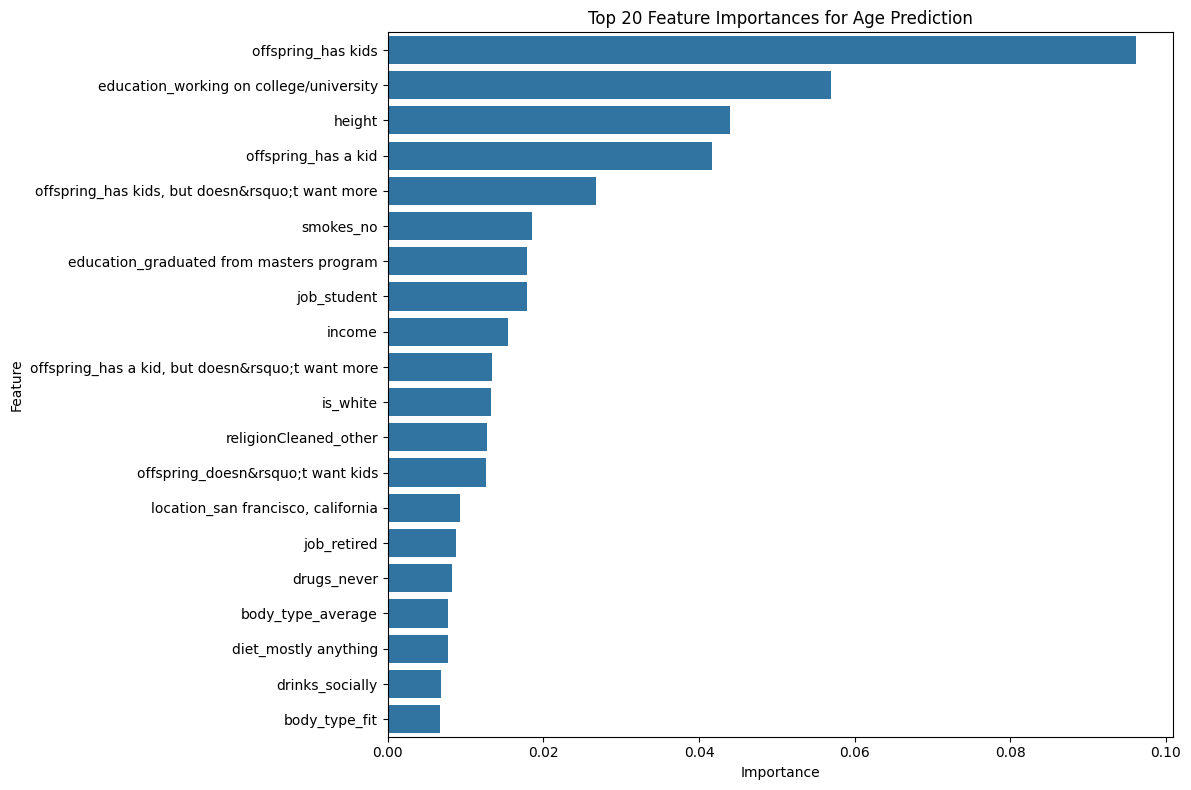

In [56]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_age.head(20))
plt.title('Top 20 Feature Importances for Age Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

####Height
Create a train and test data sets with 'height' as target variable.

In [57]:
# Create X and y for height prediction
X_height_raw = df_profiles_dummy.drop('height', axis=1)
y_height_raw = df_profiles_dummy['height']

# Combine X and y to easily drop rows where y is NaN
# Using .to_frame() to ensure y is a DataFrame to be concatenated
df_height_combined = pd.concat([X_height_raw, y_height_raw.rename('target_height')], axis=1)

# Drop rows where the target_height is NaN
df_height_combined_cleaned = df_height_combined.dropna(subset=['target_height'])

# Separate X and y again from the cleaned combined DataFrame
X_height = df_height_combined_cleaned.drop('target_height', axis=1)
y_height = df_height_combined_cleaned['target_height']


X_train_height, X_test_height, y_train_height, y_test_height = train_test_split(X_height, y_height, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train_height.shape}")
print(f"X_test shape: {X_test_height.shape}")
print(f"y_train shape: {y_train_height.shape}")
print(f"y_test shape: {y_test_height.shape}")

X_train shape: (47954, 761)
X_test shape: (11989, 761)
y_train shape: (47954,)
y_test shape: (11989,)


Create an instance of RandomForestRegressor and fit it on a training data set.

In [58]:
# Create a RandomForestRegressor model instance
model_height = RandomForestRegressor(random_state=42)

# Explicitly check and drop NaNs from y_train_height and align X_train_height
if y_train_height.isnull().any():
    print("Warning: y_train_height still contains NaN values. Dropping them now.")
    original_indices = y_train_height.index
    y_train_height_cleaned = y_train_height.dropna()
    # Realign X_train_height to match the cleaned y_train_height
    X_train_height_cleaned = X_train_height.loc[y_train_height_cleaned.index]
    y_train_height = y_train_height_cleaned
    X_train_height = X_train_height_cleaned
else:
    print("y_train_height is clean (no NaNs).")

# Train the model
model_height.fit(X_train_height, y_train_height)

print("RandomForestRegressor model for height prediction created and trained.")

y_train_height is clean (no NaNs).
RandomForestRegressor model for height prediction created and trained.


Predict values of 'height' on a test data set.

In [59]:
y_pred_height = model_height.predict(X_test_height)
print("Predicted heights for X_test (first 5 values):")
print(y_pred_height[:5])

Predicted heights for X_test (first 5 values):
[71.71 67.89 64.61 67.95 71.46]


Evaluate model performance using 'mean_squared_error' and 'r2_score' from sklearn.metrics

In [60]:
# Calculate Mean Squared Error
mse_height = mean_squared_error(y_test_height, y_pred_height)

# Calculate Root Mean Squared Error
rmse_height = np.sqrt(mse_height)

# Calculate R-squared score
r2_height = r2_score(y_test_height, y_pred_height)

print(f"Root Mean Squared Error (RMSE): {rmse_height:.2f}")
print(f"R-squared (R2) Score: {r2_height:.2f}")

Root Mean Squared Error (RMSE): 2.98
R-squared (R2) Score: 0.45


RMSE indicates that, on average, the model's predictions are about 2.98 inches off from the actual height. The R-squared score of 0.45 suggests that approximately 41% of the variance in age can be explained by the model. Not a bad result.

#### Feature Importance for Height Prediction

Feature importance quantifies the contribution of each feature to the model's prediction. A higher importance score indicates that the feature has a greater impact on the target variable (height in this case). Understanding feature importance can provide insights into the underlying relationships in the data and help in feature selection or model interpretation.

In [61]:
feature_importances_height = model_height.feature_importances_
features_height = X_train_height.columns

# Create a DataFrame for better visualization
importance_df_height = pd.DataFrame({'Feature': features_height, 'Importance': feature_importances_height})

# Sort features by importance
importance_df_height = importance_df_height.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
display(importance_df_height.head(20))

,Feature,Importance
680,sex_f,0.240168
681,sex_m,0.189222
0,age,0.040453
2,is_white,0.023594
6,is_asian,0.016195
1,income,0.011105
326,diet_mostly anything,0.006183
347,drugs_never,0.006169
558,"location_san francisco, california",0.005900
359,education_graduated from college/university,0.005512


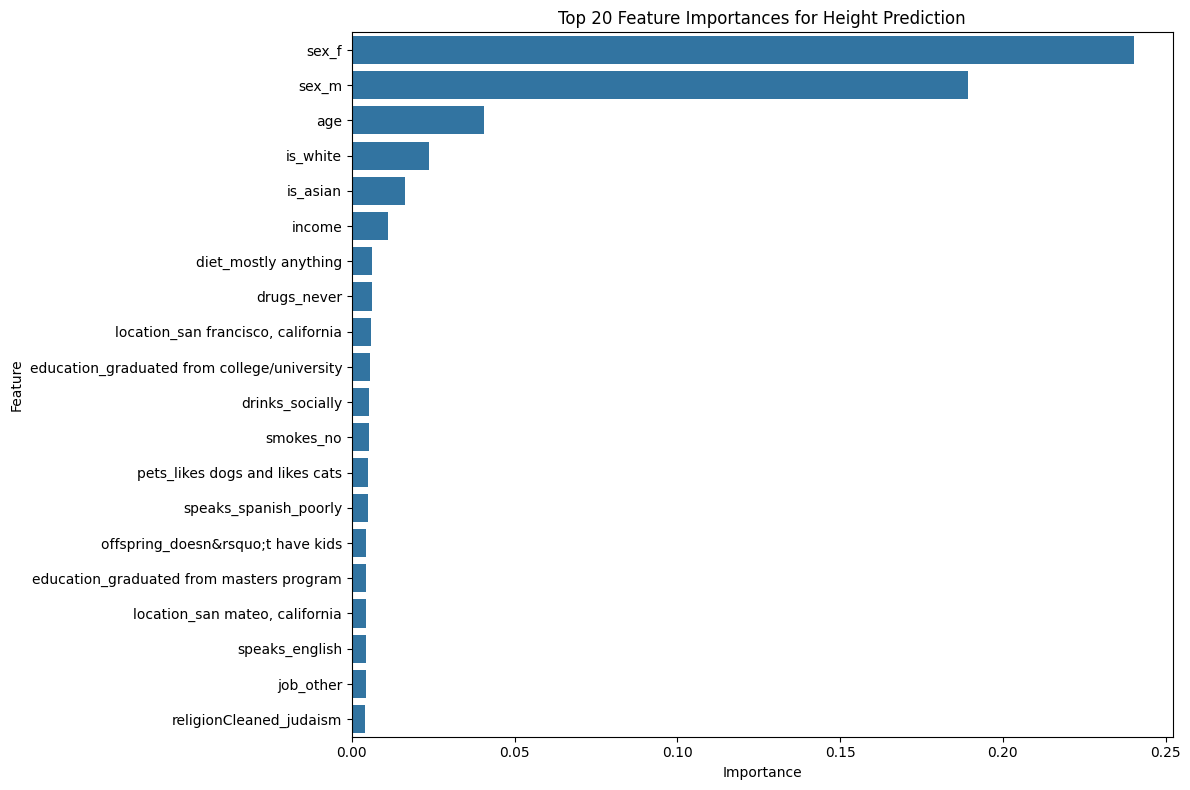

In [62]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_height.head(20))
plt.title('Top 20 Feature Importances for Height Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Regression using XGBoost

#### Age (XGBoost Regressor)

We will now use `XGBRegressor` to predict the 'age' of users, following a similar methodology to the Random Forest Regressor.

In [63]:
# Reuse X_age and y_age created earlier
# X_age = df_profiles_dummy.drop('age', axis=1)
# y_age = df_profiles_dummy['age']

# Split the data into training and testing sets
X_train_age_xgb, X_test_age_xgb, y_train_age_xgb, y_test_age_xgb = train_test_split(X_age, y_age, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train_age_xgb.shape}")
print(f"X_test shape: {X_test_age_xgb.shape}")
print(f"y_train shape: {y_train_age_xgb.shape}")
print(f"y_test shape: {y_test_age_xgb.shape}")

X_train shape: (47956, 761)
X_test shape: (11990, 761)
y_train shape: (47956,)
y_test shape: (11990,)


Create an instance of `XGBRegressor` and fit it on the training data.

In [64]:
# Create an XGBRegressor model instance
model_age_xgb = XGBRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Train the model
model_age_xgb.fit(X_train_age_xgb, y_train_age_xgb)

print("XGBRegressor model for age prediction created and trained.")

XGBRegressor model for age prediction created and trained.


Predict 'age' values on the test dataset and evaluate the model's performance.

In [65]:
# Predict values on the test data set
y_pred_age_xgb = model_age_xgb.predict(X_test_age_xgb)
print("Predicted ages for X_test (first 5 values):")
print(y_pred_age_xgb[:5])

# Calculate Mean Squared Error
mse_age_xgb = mean_squared_error(y_test_age_xgb, y_pred_age_xgb)

# Calculate Root Mean Squared Error
rmse_age_xgb = np.sqrt(mse_age_xgb)

# Calculate R-squared score
r2_age_xgb = r2_score(y_test_age_xgb, y_pred_age_xgb)

print(f"\nRoot Mean Squared Error (RMSE) for XGBoost: {rmse_age_xgb:.2f}")
print(f"R-squared (R2) Score for XGBoost: {r2_age_xgb:.2f}")

Predicted ages for X_test (first 5 values):
[28.177761 32.89339  27.684975 30.301918 27.685839]

Root Mean Squared Error (RMSE) for XGBoost: 7.28
R-squared (R2) Score for XGBoost: 0.41


RMSE indicates that, on average, the model's predictions are about 7.28 years off from the actual age. The R-squared score of 0.38 suggests that approximately 41% of the variance in age can be explained by the model. Not a bad result also.

#### Feature Importance for Age Prediction (XGBoost)

Let's analyze the feature importances from the XGBoost model for age prediction.

Top 20 Feature Importances for Age Prediction (XGBoost):


,Feature,Importance
611,offspring_has kids,0.127189
614,"offspring_has kids, but doesn&rsquo;t want more",0.047701
607,offspring_has a kid,0.037414
374,education_working on college/university,0.037096
610,"offspring_has a kid, but doesn&rsquo;t want more",0.030648
362,education_graduated from masters program,0.021939
606,offspring_doesn&rsquo;t want kids,0.017487
400,job_student,0.016427
748,religionCleaned_other,0.014710
381,education_working on two-year college,0.013732


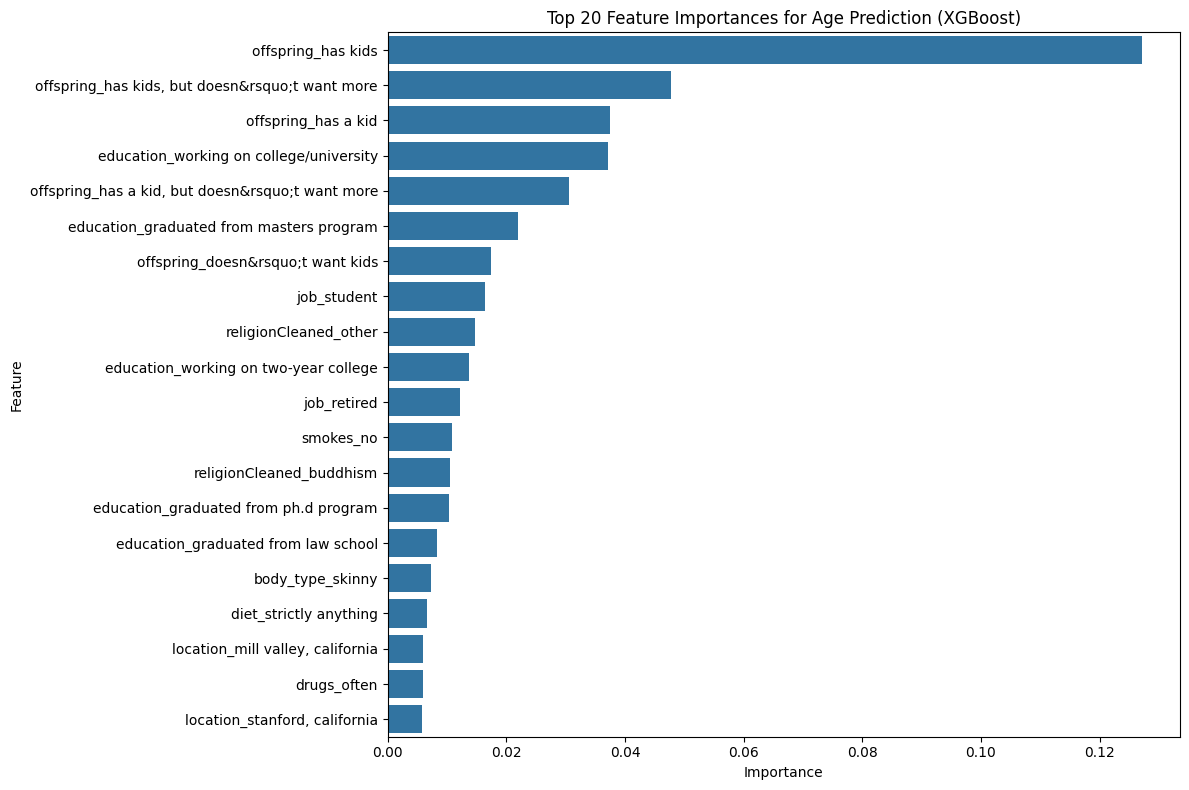

In [66]:
feature_importances_age_xgb = model_age_xgb.feature_importances_
features_age_xgb = X_train_age_xgb.columns

# Create a DataFrame for better visualization
importance_df_age_xgb = pd.DataFrame({'Feature': features_age_xgb, 'Importance': feature_importances_age_xgb})

# Sort features by importance
importance_df_age_xgb = importance_df_age_xgb.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances for Age Prediction (XGBoost):")
display(importance_df_age_xgb.head(20))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_age_xgb.head(20))
plt.title('Top 20 Feature Importances for Age Prediction (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Height (XGBoost Regressor)

Now, we will apply `XGBRegressor` to predict the 'height' of users, following the same steps.

In [67]:
# Reuse X_height and y_height created earlier
# X_height = df_height_combined_cleaned.drop('target_height', axis=1)
# y_height = df_height_combined_cleaned['target_height']

# Split the data into training and testing sets
X_train_height_xgb, X_test_height_xgb, y_train_height_xgb, y_test_height_xgb = train_test_split(X_height, y_height, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train_height_xgb.shape}")
print(f"X_test shape: {X_test_height_xgb.shape}")
print(f"y_train shape: {y_train_height_xgb.shape}")
print(f"y_test shape: {y_test_height_xgb.shape}")

X_train shape: (47954, 761)
X_test shape: (11989, 761)
y_train shape: (47954,)
y_test shape: (11989,)


Create an instance of `XGBRegressor` and fit it on the training data for height prediction.

In [68]:
# Create an XGBRegressor model instance
model_height_xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Train the model
model_height_xgb.fit(X_train_height_xgb, y_train_height_xgb)

print("XGBRegressor model for height prediction created and trained.")

XGBRegressor model for height prediction created and trained.


Predict 'height' values on the test dataset and evaluate the model's performance.

In [69]:
# Predict values on the test data set
y_pred_height_xgb = model_height_xgb.predict(X_test_height_xgb)
print("Predicted heights for X_test (first 5 values):")
print(y_pred_height_xgb[:5])

# Calculate Mean Squared Error
mse_height_xgb = mean_squared_error(y_test_height_xgb, y_pred_height_xgb)

# Calculate Root Mean Squared Error
rmse_height_xgb = np.sqrt(mse_height_xgb)

# Calculate R-squared score
r2_height_xgb = r2_score(y_test_height_xgb, y_pred_height_xgb)

print(f"\nRoot Mean Squared Error (RMSE) for XGBoost: {rmse_height_xgb:.2f}")
print(f"R-squared (R2) Score for XGBoost: {r2_height_xgb:.2f}")

Predicted heights for X_test (first 5 values):
[71.54316  68.3683   65.90602  68.140335 71.5068  ]

Root Mean Squared Error (RMSE) for XGBoost: 2.94
R-squared (R2) Score for XGBoost: 0.47


RMSE indicates that, on average, the model's predictions are about 2.94 inches off from the actual height. The R-squared score of 0.47 suggests that approximately 41% of the variance in age can be explained by the model. Not a bad result also.

#### Feature Importance for Height Prediction (XGBoost)

Let's examine which features are most influential in predicting a user's height using the XGBoost model.

Top 20 Feature Importances for Height Prediction (XGBoost):


,Feature,Importance
680,sex_f,0.516173
2,is_white,0.017151
6,is_asian,0.015591
51,speaks_other_poorly,0.008472
701,sign_gemini but it doesn&rsquo;t matter,0.007573
747,religionCleaned_judaism,0.007174
564,"location_san mateo, california",0.006193
78,speaks_hebrew_poorly,0.006163
17,speaks_german_poorly,0.005195
4,is_latin,0.004951


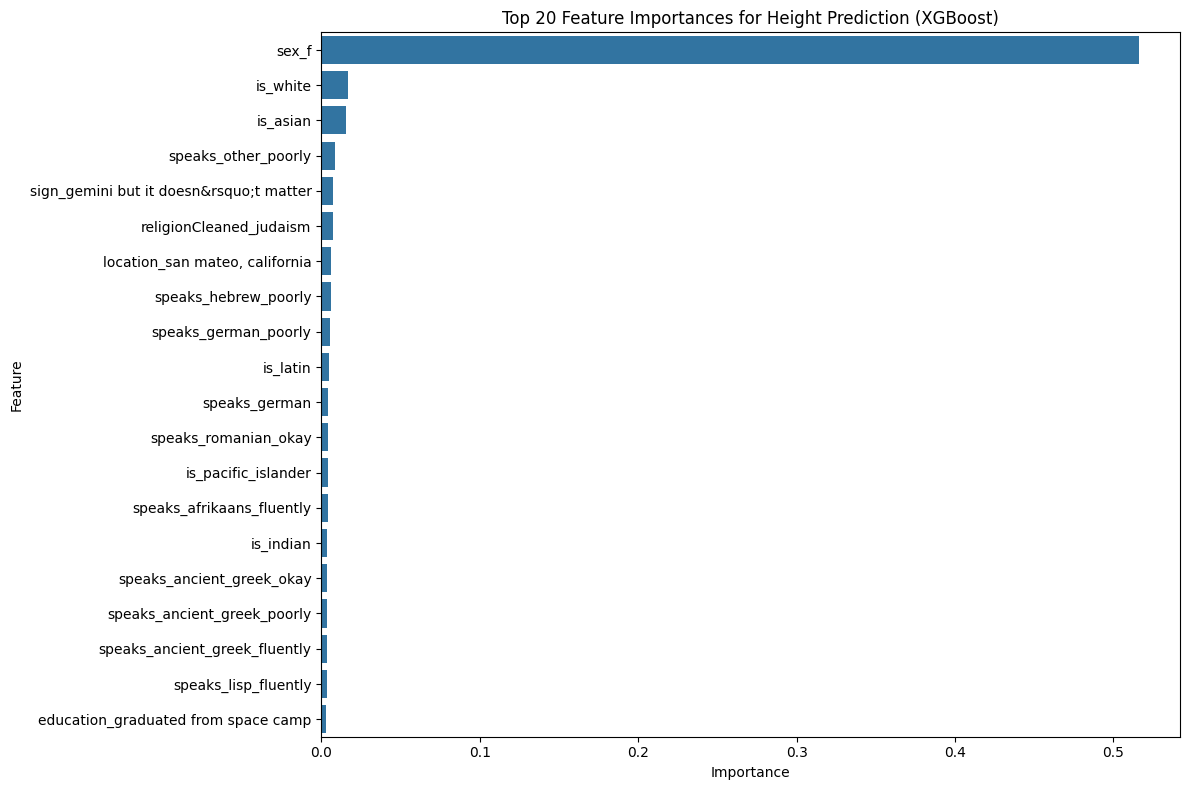

In [70]:
feature_importances_height_xgb = model_height_xgb.feature_importances_
features_height_xgb = X_train_height_xgb.columns

# Create a DataFrame for better visualization
importance_df_height_xgb = pd.DataFrame({'Feature': features_height_xgb, 'Importance': feature_importances_height_xgb})

# Sort features by importance
importance_df_height_xgb = importance_df_height_xgb.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances for Height Prediction (XGBoost):")
display(importance_df_height_xgb.head(20))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_height_xgb.head(20))
plt.title('Top 20 Feature Importances for Height Prediction (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Regression models overview.

### Regression using CatBoost

#### Age (CatBoost Regressor)

We will now use `CatBoostRegressor` to predict the 'age' of users, following a similar methodology to the other regressors.

In [71]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [72]:
from catboost import CatBoostRegressor

# Reuse X_age and y_age created earlier from the original df_profiles_dummy
# X_age = df_profiles_dummy.drop('age', axis=1)
# y_age = df_profiles_dummy['age']

# Split the data into training and testing sets (re-using the same split as XGBoost for consistency)
X_train_age_cb, X_test_age_cb, y_train_age_cb, y_test_age_cb = X_train_age_xgb, X_test_age_xgb, y_train_age_xgb, y_test_age_xgb

print(f"X_train shape: {X_train_age_cb.shape}")
print(f"X_test shape: {X_test_age_cb.shape}")
print(f"y_train shape: {y_train_age_cb.shape}")
print(f"y_test shape: {y_test_age_cb.shape}")

X_train shape: (47956, 761)
X_test shape: (11990, 761)
y_train shape: (47956,)
y_test shape: (11990,)


Create an instance of `CatBoostRegressor` and fit it on the training data.

In [73]:
# Create a CatBoostRegressor model instance
model_age_cb = CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False) # verbose=0 to suppress output, allow_writing_files=False for Colab

# Train the model
model_age_cb.fit(X_train_age_cb, y_train_age_cb)

print("CatBoostRegressor model for age prediction created and trained.")

CatBoostRegressor model for age prediction created and trained.


Predict 'age' values on the test dataset and evaluate the model's performance.

In [74]:
# Predict values on the test data set
y_pred_age_cb = model_age_cb.predict(X_test_age_cb)
print("Predicted ages for X_test (first 5 values):")
print(y_pred_age_cb[:5])

# Calculate Mean Squared Error
mse_age_cb = mean_squared_error(y_test_age_cb, y_pred_age_cb)

# Calculate Root Mean Squared Error
rmse_age_cb = np.sqrt(mse_age_cb)

# Calculate R-squared score
r2_age_cb = r2_score(y_test_age_cb, y_pred_age_cb)

print(f"\nRoot Mean Squared Error (RMSE) for CatBoost: {rmse_age_cb:.2f}")
print(f"R-squared (R2) Score for CatBoost: {r2_age_cb:.2f}")

Predicted ages for X_test (first 5 values):
[27.27155037 33.71729463 27.14467212 29.85828673 28.62978929]

Root Mean Squared Error (RMSE) for CatBoost: 7.16
R-squared (R2) Score for CatBoost: 0.43


RMSE indicates that, on average, the model's predictions are about 7.18 years off from the actual age. The R-squared score of 0.43 suggests that approximately 43% of the variance in age can be explained by the model. This shows a slight improvement over XGBoost.

#### Feature Importance for Age Prediction (CatBoost)

Let's analyze the feature importances from the CatBoost model for age prediction.

Top 20 Feature Importances for Age Prediction (CatBoost):


,Feature,Importance
611,offspring_has kids,15.678593
607,offspring_has a kid,7.454115
374,education_working on college/university,6.306612
400,job_student,4.542914
614,"offspring_has kids, but doesn&rsquo;t want more",4.073697
730,smokes_no,3.741306
362,education_graduated from masters program,3.400182
1,income,3.255820
748,religionCleaned_other,2.715615
2,is_white,2.423383


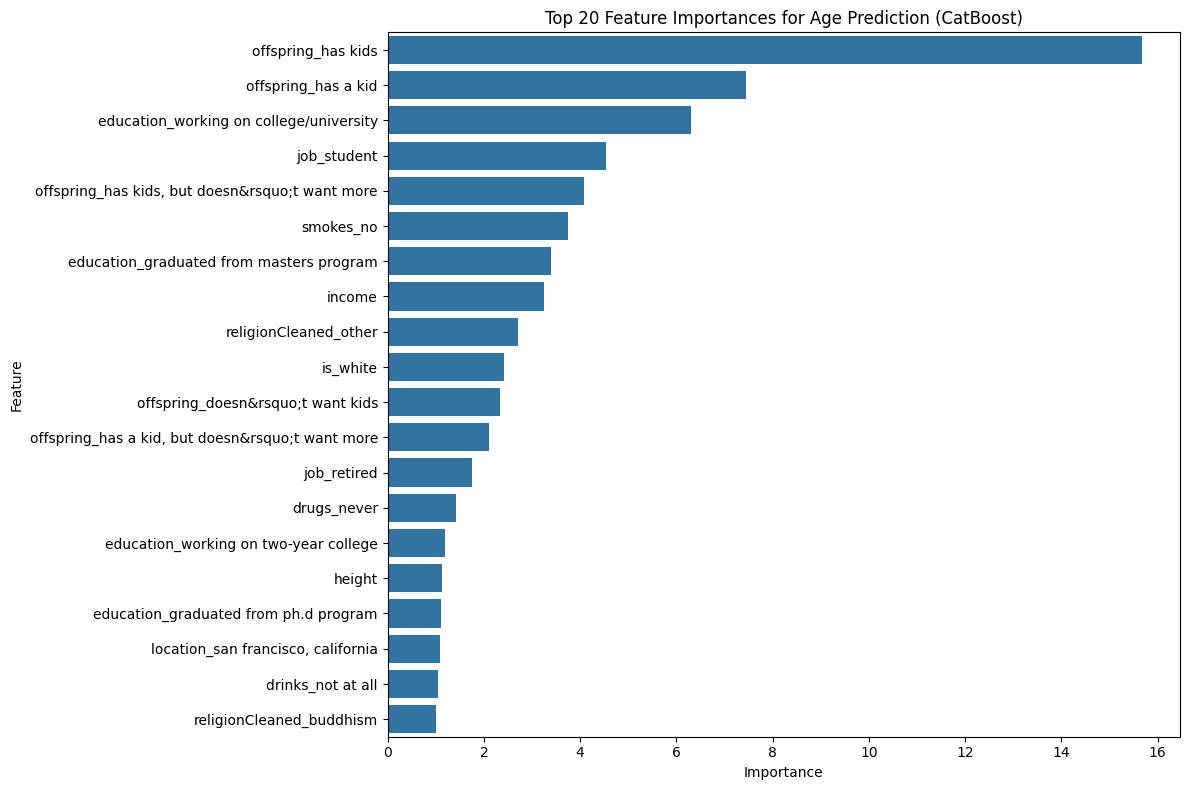

In [75]:
from catboost import Pool

# Create a CatBoost Pool object from the training data
train_pool_age_cb = Pool(X_train_age_cb, y_train_age_cb)

feature_importances_age_cb = model_age_cb.get_feature_importance(data=train_pool_age_cb)
features_age_cb = X_train_age_cb.columns

# Create a DataFrame for better visualization
importance_df_age_cb = pd.DataFrame({'Feature': features_age_cb, 'Importance': feature_importances_age_cb})

# Sort features by importance
importance_df_age_cb = importance_df_age_cb.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances for Age Prediction (CatBoost):")
display(importance_df_age_cb.head(20))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_age_cb.head(20))
plt.title('Top 20 Feature Importances for Age Prediction (CatBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Height (CatBoost Regressor)

Now, we will apply `CatBoostRegressor` to predict the 'height' of users, following the same steps.

In [76]:
# Reuse X_height and y_height created earlier
# X_height = df_height_combined_cleaned.drop('target_height', axis=1)
# y_height = df_height_combined_cleaned['target_height']

# Split the data into training and testing sets (re-using the same split as XGBoost for consistency)
X_train_height_cb, X_test_height_cb, y_train_height_cb, y_test_height_cb = X_train_height_xgb, X_test_height_xgb, y_train_height_xgb, y_test_height_xgb

print(f"X_train shape: {X_train_height_cb.shape}")
print(f"X_test shape: {X_test_height_cb.shape}")
print(f"y_train shape: {y_train_height_cb.shape}")
print(f"y_test shape: {y_test_height_cb.shape}")

X_train shape: (47954, 761)
X_test shape: (11989, 761)
y_train shape: (47954,)
y_test shape: (11989,)


Create an instance of `CatBoostRegressor` and fit it on the training data for height prediction.

In [77]:
# Create a CatBoostRegressor model instance
model_height_cb = CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False)

# Train the model
model_height_cb.fit(X_train_height_cb, y_train_height_cb)

print("CatBoostRegressor model for height prediction created and trained.")

CatBoostRegressor model for height prediction created and trained.


Predict 'height' values on the test dataset and evaluate the model's performance.

In [78]:
# Predict values on the test data set
y_pred_height_cb = model_height_cb.predict(X_test_height_cb)
print("Predicted heights for X_test (first 5 values):")
print(y_pred_height_cb[:5])

# Calculate Mean Squared Error
mse_height_cb = mean_squared_error(y_test_height_cb, y_pred_height_cb)

# Calculate Root Mean Squared Error
rmse_height_cb = np.sqrt(mse_height_cb)

# Calculate R-squared score
r2_height_cb = r2_score(y_test_height_cb, y_pred_height_cb)

print(f"\nRoot Mean Squared Error (RMSE) for CatBoost: {rmse_height_cb:.2f}")
print(f"R-squared (R2) Score for CatBoost: {r2_height_cb:.2f}")

Predicted heights for X_test (first 5 values):
[71.31391082 68.49135963 65.63267356 68.37851327 71.47947277]

Root Mean Squared Error (RMSE) for CatBoost: 2.91
R-squared (R2) Score for CatBoost: 0.48


RMSE indicates that, on average, the model's predictions are about 2.92 inches off from the actual height. The R-squared score of 0.48 suggests that approximately 48% of the variance in height can be explained by the model. CatBoost shows slightly better performance than XGBoost for height prediction.

#### Feature Importance for Height Prediction (CatBoost)

Let's examine which features are most influential in predicting a user's height using the CatBoost model.

Top 20 Feature Importances for Height Prediction (CatBoost):


,Feature,Importance
681,sex_m,41.399513
680,sex_f,34.636273
6,is_asian,3.197126
2,is_white,3.128161
0,age,1.168237
10,is_hispanic,0.749969
747,religionCleaned_judaism,0.674104
1,income,0.589442
9,is_pacific_islander,0.481104
3,is_black,0.389383


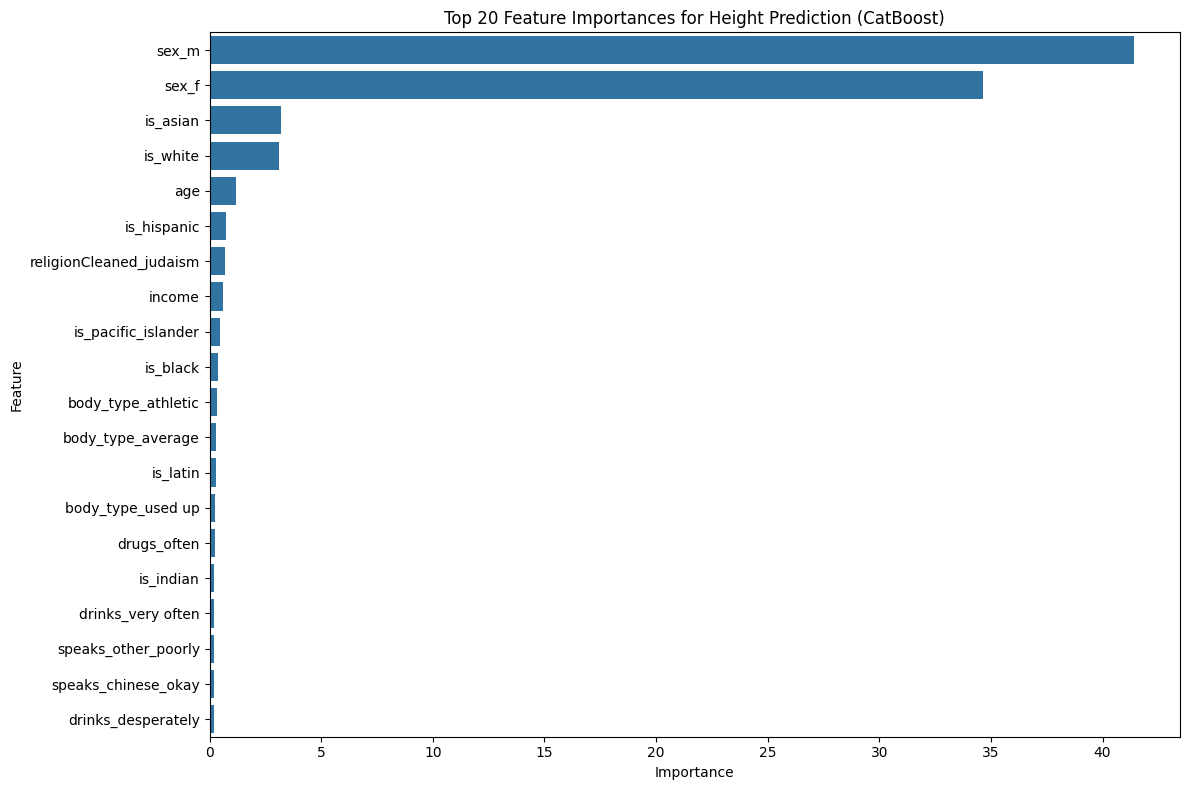

In [79]:
from catboost import Pool

# Create a CatBoost Pool object from the training data
train_pool_height_cb = Pool(X_train_height_cb, y_train_height_cb)

feature_importances_height_cb = model_height_cb.get_feature_importance(data=train_pool_height_cb)
features_height_cb = X_train_height_cb.columns

# Create a DataFrame for better visualization
importance_df_height_cb = pd.DataFrame({'Feature': features_height_cb, 'Importance': feature_importances_height_cb})

# Sort features by importance
importance_df_height_cb = importance_df_height_cb.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances for Height Prediction (CatBoost):")
display(importance_df_height_cb.head(20))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_height_cb.head(20))
plt.title('Top 20 Feature Importances for Height Prediction (CatBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Comparison of Regression Models

Let's compare the performance of the three regression models (RandomForest, XGBoost, and CatBoost) for both age and height prediction using RMSE and R-squared scores.

In [80]:
# Store the results in a DataFrame
results = {
    'Model': ['RandomForestRegressor', 'XGBRegressor', 'CatBoostRegressor'],
    'Age_RMSE': [rmse_age, rmse_age_xgb, rmse_age_cb],
    'Age_R2': [r2_age, r2_age_xgb, r2_age_cb],
    'Height_RMSE': [rmse_height, rmse_height_xgb, rmse_height_cb],
    'Height_R2': [r2_height, r2_height_xgb, r2_height_cb]
}

results_df = pd.DataFrame(results)

print("Regression Model Performance Comparison:")
display(results_df.round(2))

Regression Model Performance Comparison:


,Model,Age_RMSE,Age_R2,Height_RMSE,Height_R2
0,RandomForestRegressor,7.47,0.38,2.98,0.45
1,XGBRegressor,7.28,0.41,2.94,0.47
2,CatBoostRegressor,7.16,0.43,2.91,0.48


From the comparison table, it is evident that **CatBoostRegressor** generally performs best for both age and height prediction, achieving slightly lower RMSE and higher R-squared scores compared to RandomForestRegressor and XGBoostRegressor.

With both age and height XGBoost shows better performance than random forest regressor.

## Classification models
We will be building classification models for 'smoking', 'drugs', 'drinks', 'pets', 'sex', 'job' and 'diet' features as target variables.

###Smoking

Create a train and test data sets with 'age' as target variable.

In [81]:
# --- Ensure essential dataframes are loaded and preprocessed ---
# This block ensures df_profiles_all, df_profiles_cleared, and df_profiles_dummy
# are available, re-creating them if the kernel was reset or cells were run out of order.
if 'df_profiles_all' not in locals() and 'df_profiles_all' not in globals():
    print("Loading df_profiles_all and processing ethnicity/speaks features...")
    df_profiles_all = pd.read_csv('/content/drive/MyDrive/profiles.csv', on_bad_lines='skip', engine='python')

    # Re-create ethnicity columns
    main_groups = ['white', 'black', 'latin', 'indian', 'asian', 'native american', 'middle eastern', 'pacific islander', 'hispanic']
    for group in main_groups:
        column_name = f'is_{group.replace(" ", "_")}'
        df_profiles_all[column_name] = df_profiles_all['ethnicity'].apply(lambda x: group in str(x).lower() if pd.notna(x) else False)
    df_profiles_all = df_profiles_all.drop('ethnicity', axis=1)

    # Re-create speaks columns
    def extract_languages_with_proficiency(speaks_entry):
        if pd.isna(speaks_entry):
            return []
        languages_with_proficiency = []
        for part in speaks_entry.split(','):
            match = re.match(r'\\s*([a-zA-Z\\s]+)(?:\\s*\\((.*)\\))?', part.strip())
            if match:
                language = match.group(1).strip().lower().replace(' ', '_')
                proficiency = match.group(2)
                if proficiency:
                    proficiency = proficiency.strip().lower().replace(' ', '_')
                    languages_with_proficiency.append(f'{language}_{proficiency}')
                else:
                    languages_with_proficiency.append(language)
        return languages_with_proficiency

    # Only process 'speaks' if it exists and hasn't been processed into individual columns yet
    if 'speaks' in df_profiles_all.columns and not any(col.startswith('speaks_') for col in df_profiles_all.columns):
        all_languages_with_proficiency = df_profiles_all['speaks'].apply(extract_languages_with_proficiency).explode().unique()
        for lang_prof in all_languages_with_proficiency:
            if lang_prof and lang_prof != 'nan':
                df_profiles_all[f'speaks_{lang_prof}'] = df_profiles_all['speaks'].apply(lambda x: lang_prof in extract_languages_with_proficiency(x))
        df_profiles_all = df_profiles_all.drop('speaks', axis=1)
    elif 'speaks' in df_profiles_all.columns:
        df_profiles_all = df_profiles_all.drop('speaks', axis=1)

if 'df_profiles_cleared' not in locals() and 'df_profiles_cleared' not in globals():
    print("Creating df_profiles_cleared by dropping essay and last_online columns...")
    essay_cols = [col for col in df_profiles_all.columns if col.startswith('essay')]
    cols_to_drop_cleared = essay_cols + ['last_online']
    df_profiles_cleared = df_profiles_all.drop(columns=[col for col in cols_to_drop_cleared if col in df_profiles_all.columns])

if 'df_profiles_dummy' not in locals() and 'df_profiles_dummy' not in globals():
    print("Creating df_profiles_dummy by one-hot encoding categorical features...")
    df_profiles_dummy = pd.get_dummies(df_profiles_cleared)

# --- Reusable function for Classification Model Training and Evaluation ---
def train_and_evaluate_classification_model(df_cleared, df_dummy, target_column):
    print(f"\n--- Training and Evaluating Classification Model for: '{target_column}' ---")

    # Filter out rows where the target column is NaN
    df_filtered_cleared = df_cleared.dropna(subset=[target_column])

    # Ensure y contains only non-null values for the target column
    y = df_filtered_cleared[target_column]

    # Align X with the filtered y by index
    # Drop target-related dummy columns from X to prevent data leakage
    target_dummy_cols = [col for col in df_dummy.columns if col.startswith(f'{target_column}_')]
    X_initial = df_dummy.drop(columns=target_dummy_cols, errors='ignore')

    # If the original target column is still in X_initial (e.g., if it's not one-hot encoded)
    if target_column in X_initial.columns:
        X_initial = X_initial.drop(columns=[target_column])

    X = X_initial.loc[y.index]

    # Handle potential discrepancies in columns after filtering (e.g., if some categories disappear)
    # Align columns between X and X_test later if necessary, but for now ensure consistent feature set

    print(f"Filtered data size for '{target_column}': {len(y)} samples")

    if len(y) == 0 or X.empty:
        print(f"Not enough data to train a model for '{target_column}' after dropping NaNs.")
        return

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")

    # Create and train a RandomForestClassifier model instance
    model = RandomForestClassifier(random_state=42)
    print("RandomForestClassifier model created.")

    model.fit(X_train, y_train)
    print(f"RandomForestClassifier model for '{target_column}' trained.")

    # Predict values on the test data set
    y_pred = model.predict(X_test)
    print(f"Predictions for '{target_column}' made on the test set.")

    # Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    # Use 'weighted' average for precision, recall, f1-score for multi-class classification
    # and zero_division=0 to handle cases where a class has no predicted samples.
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n'{target_column}' Prediction Model Performance:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return model, X_train.columns

# --- Call the function for 'smokes' ---
model_smokes, feature_columns_smokes = train_and_evaluate_classification_model(df_profiles_cleared, df_profiles_dummy, 'smokes')



--- Training and Evaluating Classification Model for: 'smokes' ---
Filtered data size for 'smokes': 54434 samples
X_train shape: (43547, 757)
X_test shape: (10887, 757)
y_train shape: (43547,)
y_test shape: (10887,)
RandomForestClassifier model created.
RandomForestClassifier model for 'smokes' trained.
Predictions for 'smokes' made on the test set.

'smokes' Prediction Model Performance:
Accuracy: 0.81
Precision: 0.68
Recall: 0.81
F1-Score: 0.72

Classification Report:
                precision    recall  f1-score   support

            no       0.81      1.00      0.89      8779
     sometimes       0.00      0.00      0.00       758
trying to quit       0.00      0.00      0.00       296
 when drinking       0.00      0.00      0.00       608
           yes       0.78      0.03      0.06       446

      accuracy                           0.81     10887
     macro avg       0.32      0.21      0.19     10887
  weighted avg       0.68      0.81      0.72     10887



### Drugs

In [82]:
model_drugs, feature_columns_drugs = train_and_evaluate_classification_model(df_profiles_cleared, df_profiles_dummy, 'drugs')


--- Training and Evaluating Classification Model for: 'drugs' ---
Filtered data size for 'drugs': 45866 samples
X_train shape: (36692, 759)
X_test shape: (9174, 759)
y_train shape: (36692,)
y_test shape: (9174,)
RandomForestClassifier model created.
RandomForestClassifier model for 'drugs' trained.
Predictions for 'drugs' made on the test set.

'drugs' Prediction Model Performance:
Accuracy: 0.84
Precision: 0.81
Recall: 0.84
F1-Score: 0.79

Classification Report:
              precision    recall  f1-score   support

       never       0.85      0.99      0.91      7545
       often       0.00      0.00      0.00        82
   sometimes       0.65      0.16      0.26      1547

    accuracy                           0.84      9174
   macro avg       0.50      0.38      0.39      9174
weighted avg       0.81      0.84      0.79      9174



#### Feature Importance for Drugs Prediction

Let's examine which features are most influential in predicting a user's drug usage.

Top 20 Feature Importances for Drugs Prediction:


,Feature,Importance
0,age,0.047510
1,height,0.037299
728,smokes_no,0.036159
344,drinks_often,0.020457
2,income,0.016646
729,smokes_sometimes,0.016221
732,smokes_yes,0.014974
731,smokes_when drinking,0.012115
3,is_white,0.010903
357,education_graduated from college/university,0.010801


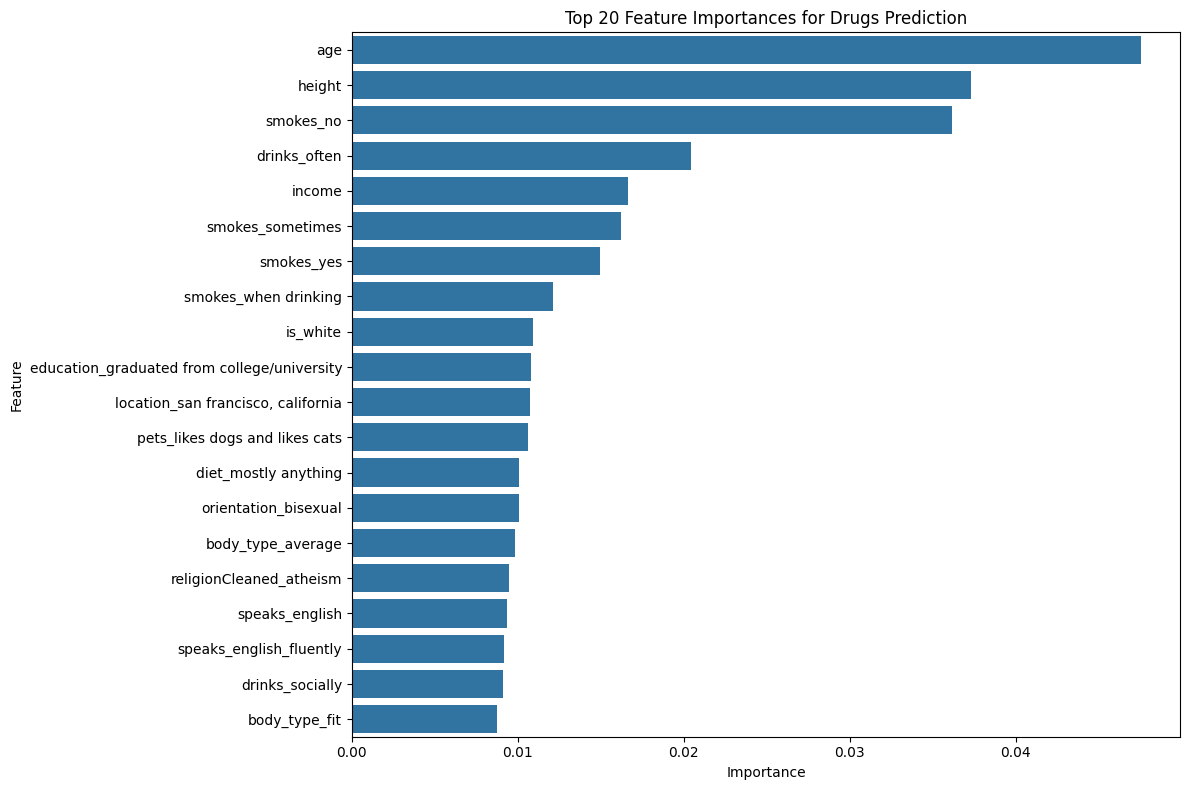

In [83]:
if model_drugs is not None:
    feature_importances_drugs = model_drugs.feature_importances_

    importance_df_drugs = pd.DataFrame({'Feature': feature_columns_drugs, 'Importance': feature_importances_drugs})
    importance_df_drugs = importance_df_drugs.sort_values(by='Importance', ascending=False)

    print("Top 20 Feature Importances for Drugs Prediction:")
    display(importance_df_drugs.head(20))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df_drugs.head(20))
    plt.title('Top 20 Feature Importances for Drugs Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### Drinks

In [84]:
model_drinks, feature_columns_drinks = train_and_evaluate_classification_model(df_profiles_cleared, df_profiles_dummy, 'drinks')


--- Training and Evaluating Classification Model for: 'drinks' ---
Filtered data size for 'drinks': 56961 samples
X_train shape: (45568, 756)
X_test shape: (11393, 756)
y_train shape: (45568,)
y_test shape: (11393,)
RandomForestClassifier model created.
RandomForestClassifier model for 'drinks' trained.
Predictions for 'drinks' made on the test set.

'drinks' Prediction Model Performance:
Accuracy: 0.73
Precision: 0.72
Recall: 0.73
F1-Score: 0.62

Classification Report:
              precision    recall  f1-score   support

 desperately       0.00      0.00      0.00        64
  not at all       0.80      0.01      0.01       653
       often       0.38      0.01      0.02      1033
      rarely       1.00      0.00      0.00      1192
    socially       0.73      1.00      0.85      8357
  very often       0.00      0.00      0.00        94

    accuracy                           0.73     11393
   macro avg       0.49      0.17      0.15     11393
weighted avg       0.72      0.73   

#### Feature Importance for Drinks Prediction

Let's examine which features are most influential in predicting a user's drinking habits.

Top 20 Feature Importances for Drinks Prediction:


,Feature,Importance
0,age,0.050819
1,height,0.042922
2,income,0.015324
629,pets_likes dogs and likes cats,0.011466
3,is_white,0.011448
13,speaks_english_fluently,0.011413
327,diet_mostly anything,0.011273
12,speaks_english,0.011171
314,body_type_average,0.010872
354,education_graduated from college/university,0.010001


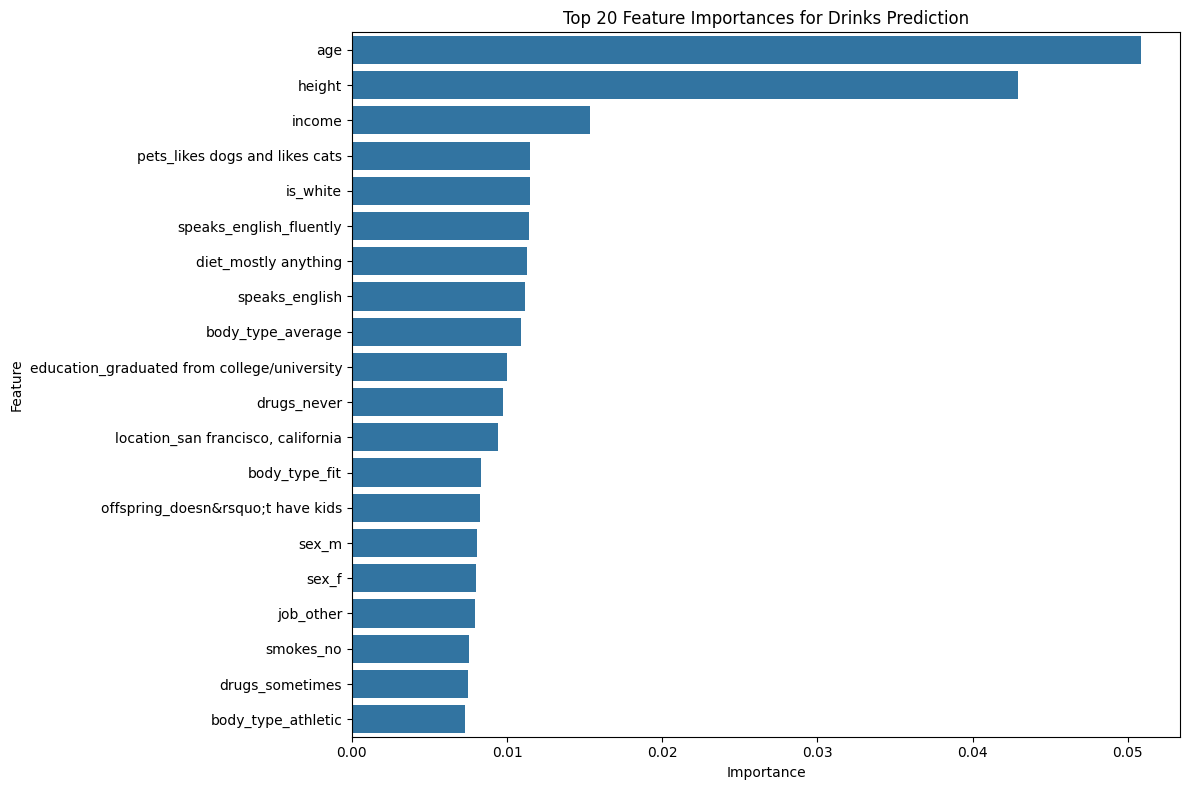

In [85]:
if model_drinks is not None:
    feature_importances_drinks = model_drinks.feature_importances_

    importance_df_drinks = pd.DataFrame({'Feature': feature_columns_drinks, 'Importance': feature_importances_drinks})
    importance_df_drinks = importance_df_drinks.sort_values(by='Importance', ascending=False)

    print("Top 20 Feature Importances for Drinks Prediction:")
    display(importance_df_drinks.head(20))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df_drinks.head(20))
    plt.title('Top 20 Feature Importances for Drinks Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### Pets

In [86]:
model_pets, feature_columns_pets = train_and_evaluate_classification_model(df_profiles_cleared, df_profiles_dummy, 'pets')


--- Training and Evaluating Classification Model for: 'pets' ---
Filtered data size for 'pets': 40025 samples
X_train shape: (32020, 747)
X_test shape: (8005, 747)
y_train shape: (32020,)
y_test shape: (8005,)
RandomForestClassifier model created.
RandomForestClassifier model for 'pets' trained.
Predictions for 'pets' made on the test set.

'pets' Prediction Model Performance:
Accuracy: 0.38
Precision: 0.28
Recall: 0.38
F1-Score: 0.27

Classification Report:
                                 precision    recall  f1-score   support

                  dislikes cats       0.00      0.00      0.00        24
                  dislikes dogs       0.00      0.00      0.00         9
dislikes dogs and dislikes cats       0.00      0.00      0.00        39
     dislikes dogs and has cats       0.00      0.00      0.00        16
   dislikes dogs and likes cats       0.00      0.00      0.00        48
                       has cats       0.00      0.00      0.00       281
                       h

#### Feature Importance for Pets Prediction

Let's examine which features are most influential in predicting a user's pet preferences.

Top 20 Feature Importances for Pets Prediction:


,Feature,Importance
0,age,0.047297
1,height,0.041987
2,income,0.015536
327,diet_mostly anything,0.013710
360,education_graduated from college/university,0.012337
314,body_type_average,0.011951
346,drinks_socially,0.011245
348,drugs_never,0.011243
559,"location_san francisco, california",0.011128
3,is_white,0.010658


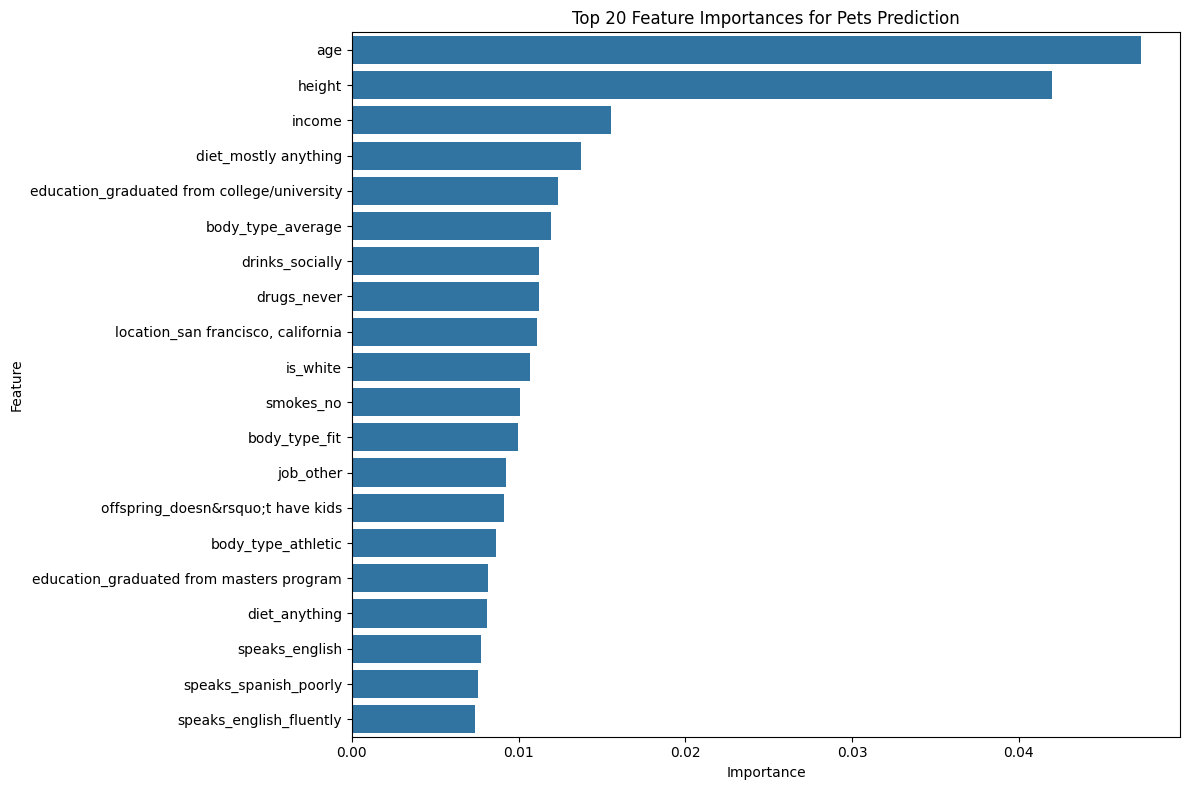

In [87]:
if model_pets is not None:
    feature_importances_pets = model_pets.feature_importances_

    importance_df_pets = pd.DataFrame({'Feature': feature_columns_pets, 'Importance': feature_importances_pets})
    importance_df_pets = importance_df_pets.sort_values(by='Importance', ascending=False)

    print("Top 20 Feature Importances for Pets Prediction:")
    display(importance_df_pets.head(20))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df_pets.head(20))
    plt.title('Top 20 Feature Importances for Pets Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### Sex

In [88]:
model_sex, feature_columns_sex = train_and_evaluate_classification_model(df_profiles_cleared, df_profiles_dummy, 'sex')


--- Training and Evaluating Classification Model for: 'sex' ---
Filtered data size for 'sex': 59946 samples
X_train shape: (47956, 760)
X_test shape: (11990, 760)
y_train shape: (47956,)
y_test shape: (11990,)
RandomForestClassifier model created.
RandomForestClassifier model for 'sex' trained.
Predictions for 'sex' made on the test set.

'sex' Prediction Model Performance:
Accuracy: 0.89
Precision: 0.89
Recall: 0.89
F1-Score: 0.89

Classification Report:
              precision    recall  f1-score   support

           f       0.88      0.83      0.85      4824
           m       0.89      0.92      0.91      7166

    accuracy                           0.89     11990
   macro avg       0.88      0.88      0.88     11990
weighted avg       0.89      0.89      0.89     11990



#### Feature Importance for Sex Prediction

Let's examine which features are most influential in predicting a user's sex.

Top 20 Feature Importances for Sex Prediction:


,Feature,Importance
1,height,0.315695
315,body_type_curvy,0.046386
0,age,0.030300
313,body_type_athletic,0.020127
2,income,0.015089
386,job_computer / hardware / software,0.012166
618,orientation_bisexual,0.009058
3,is_white,0.008745
559,"location_san francisco, california",0.007403
348,drugs_never,0.007388


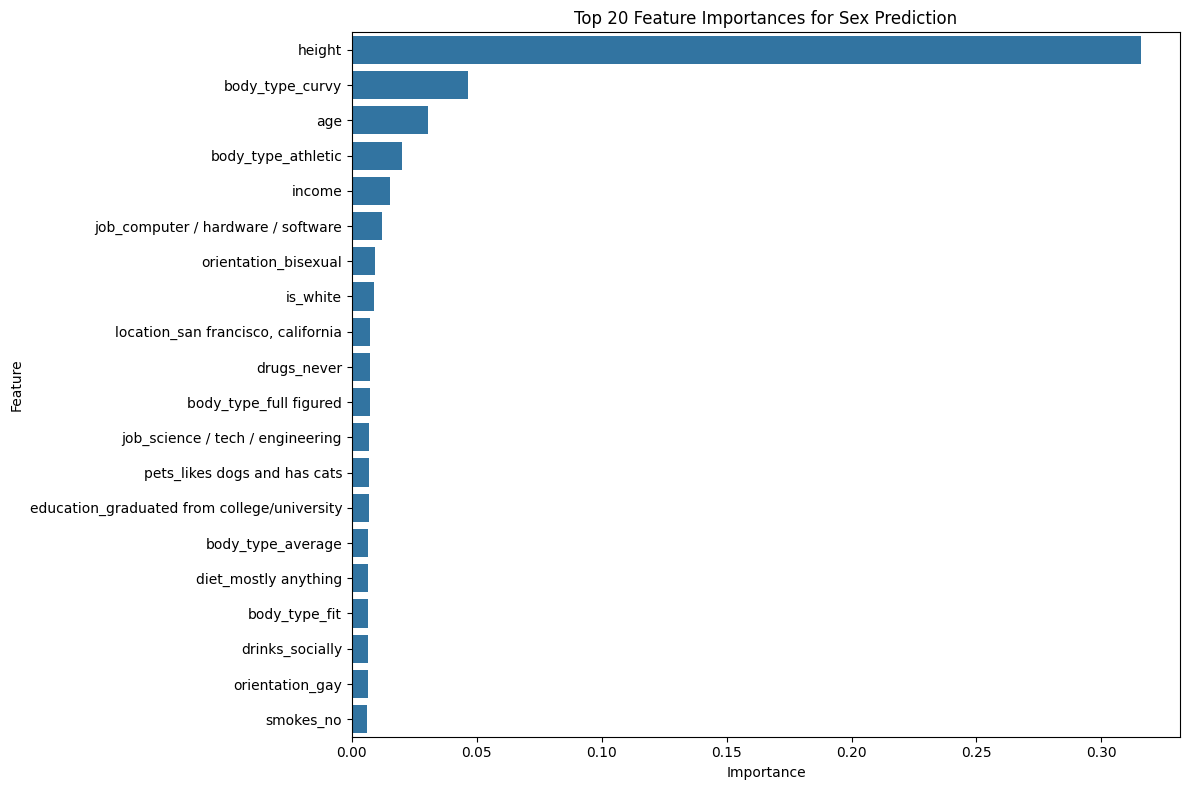

In [89]:
if model_sex is not None:
    feature_importances_sex = model_sex.feature_importances_

    importance_df_sex = pd.DataFrame({'Feature': feature_columns_sex, 'Importance': feature_importances_sex})
    importance_df_sex = importance_df_sex.sort_values(by='Importance', ascending=False)

    print("Top 20 Feature Importances for Sex Prediction:")
    display(importance_df_sex.head(20))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df_sex.head(20))
    plt.title('Top 20 Feature Importances for Sex Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### Job

In [90]:
model_job, feature_columns_job = train_and_evaluate_classification_model(df_profiles_cleared, df_profiles_dummy, 'job')


--- Training and Evaluating Classification Model for: 'job' ---
Filtered data size for 'job': 51748 samples
X_train shape: (41398, 741)
X_test shape: (10350, 741)
y_train shape: (41398,)
y_test shape: (10350,)
RandomForestClassifier model created.
RandomForestClassifier model for 'job' trained.
Predictions for 'job' made on the test set.

'job' Prediction Model Performance:
Accuracy: 0.26
Precision: 0.25
Recall: 0.26
F1-Score: 0.23

Classification Report:
                                   precision    recall  f1-score   support

      artistic / musical / writer       0.16      0.11      0.14       888
banking / financial / real estate       0.13      0.05      0.07       453
        clerical / administrative       0.00      0.00      0.00       161
   computer / hardware / software       0.26      0.42      0.32       942
     construction / craftsmanship       0.28      0.04      0.08       204
             education / academia       0.23      0.16      0.19       703
            e

#### Feature Importance for Job Prediction

Let's examine which features are most influential in predicting a user's job.

Top 20 Feature Importances for Job Prediction:


,Feature,Importance
0,age,0.054216
1,height,0.042586
2,income,0.017964
327,diet_mostly anything,0.014914
614,pets_likes dogs and likes cats,0.013176
3,is_white,0.012611
314,body_type_average,0.012067
346,drinks_socially,0.011546
348,drugs_never,0.011351
316,body_type_fit,0.010970


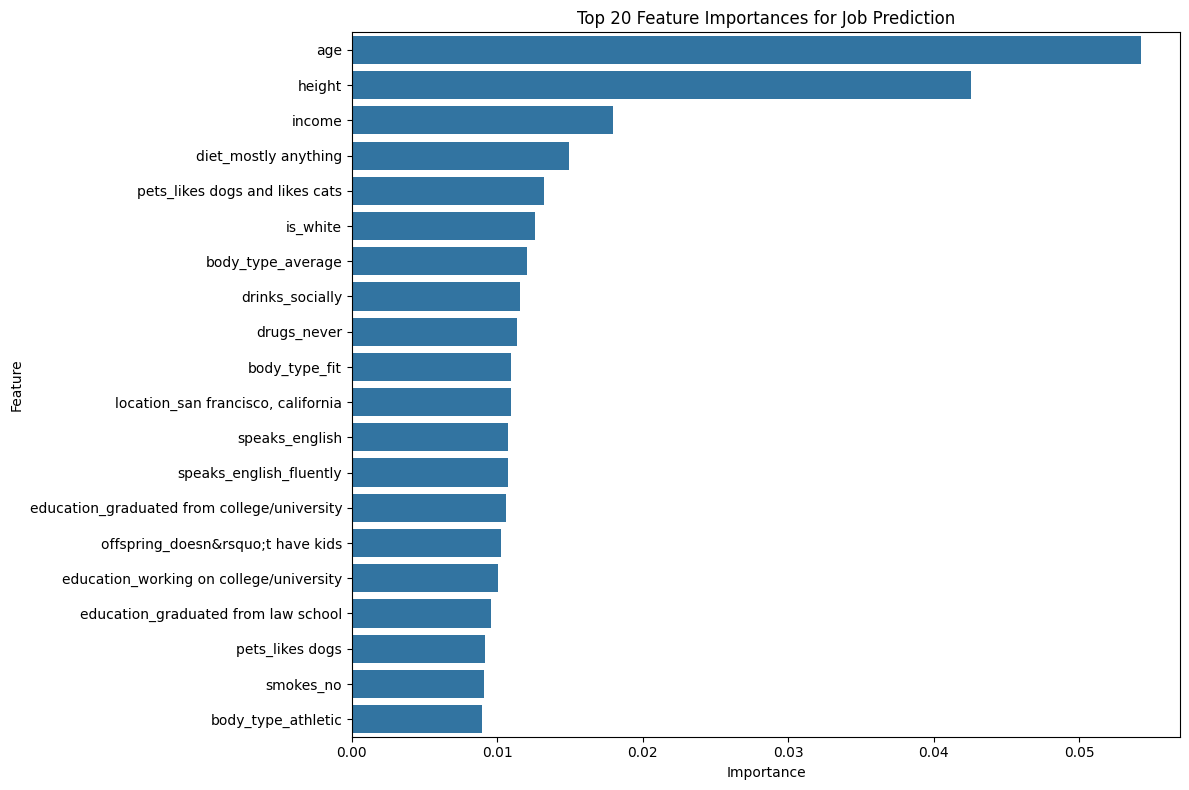

In [91]:
if model_job is not None:
    feature_importances_job = model_job.feature_importances_

    importance_df_job = pd.DataFrame({'Feature': feature_columns_job, 'Importance': feature_importances_job})
    importance_df_job = importance_df_job.sort_values(by='Importance', ascending=False)

    print("Top 20 Feature Importances for Job Prediction:")
    display(importance_df_job.head(20))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df_job.head(20))
    plt.title('Top 20 Feature Importances for Job Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### Diet

In [92]:
model_diet, feature_columns_diet = train_and_evaluate_classification_model(df_profiles_cleared, df_profiles_dummy, 'diet')


--- Training and Evaluating Classification Model for: 'diet' ---
Filtered data size for 'diet': 35551 samples
X_train shape: (28440, 744)
X_test shape: (7111, 744)
y_train shape: (28440,)
y_test shape: (7111,)
RandomForestClassifier model created.
RandomForestClassifier model for 'diet' trained.
Predictions for 'diet' made on the test set.

'diet' Prediction Model Performance:
Accuracy: 0.47
Precision: 0.37
Recall: 0.47
F1-Score: 0.32

Classification Report:
                     precision    recall  f1-score   support

           anything       0.34      0.05      0.08      1237
              halal       0.00      0.00      0.00         2
             kosher       0.00      0.00      0.00         2
    mostly anything       0.47      0.97      0.63      3317
       mostly halal       0.00      0.00      0.00        10
      mostly kosher       0.00      0.00      0.00        17
       mostly other       0.00      0.00      0.00       201
       mostly vegan       0.00      0.00      0

#### Feature Importance for Diet Prediction

Let's examine which features are most influential in predicting a user's diet.

Top 20 Feature Importances for Diet Prediction:


,Feature,Importance
0,age,0.047860
1,height,0.041612
2,income,0.015908
342,education_graduated from college/university,0.012939
541,"location_san francisco, california",0.012904
314,body_type_average,0.011902
617,pets_likes dogs and likes cats,0.011824
316,body_type_fit,0.011575
3,is_white,0.011171
330,drugs_never,0.010745


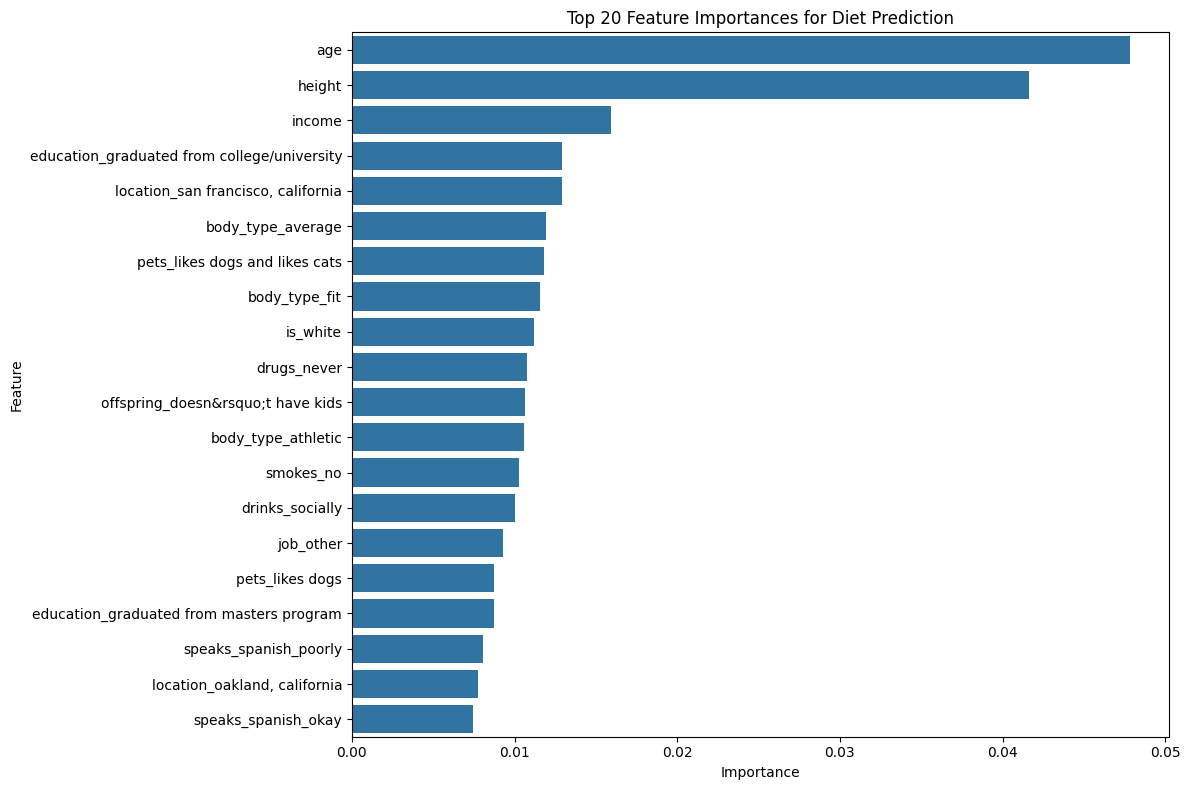

In [93]:
if model_diet is not None:
    feature_importances_diet = model_diet.feature_importances_

    importance_df_diet = pd.DataFrame({'Feature': feature_columns_diet, 'Importance': feature_importances_diet})
    importance_df_diet = importance_df_diet.sort_values(by='Importance', ascending=False)

    print("Top 20 Feature Importances for Diet Prediction:")
    display(importance_df_diet.head(20))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df_diet.head(20))
    plt.title('Top 20 Feature Importances for Diet Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

# Conclusion

We can use machine learning techniques to effectively fill in missing values in a dataset, potentially enhancing the performance of recommendation models. These models are a vital component of any dating application's backend.